In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pathlib, os
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

# ── Sklearn — Data ────────────────────────────────────────────────────────────
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans

# ── Sklearn — Models ──────────────────────────────────────────────────────────
from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, ElasticNetCV,
    BayesianRidge, lasso_path
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

print('All imports OK')

# ── SHAP & Optuna ─────────────────────────────────────────────────────────────
import optuna, shap


All imports OK


In [2]:
# 1. Get the directory where this notebook is running
current_dir = pathlib.Path().resolve()

# 2. Force Python's active working directory to be this folder
os.chdir(current_dir)

# 3. Force dataset downloaders to use a local cache directory instead of your root user folder
os.environ["XDG_CACHE_HOME"] = str(current_dir / ".cache")
os.environ["HF_HOME"] = str(current_dir / ".cache" / "huggingface") # Safe keeping for future downloads

print(f" Working Directory set to: {os.getcwd()}")
print(f" Local Cache Directory set to: {current_dir / '.cache'}")

import os
os.chdir(r"C:\Users\Sanjana Raman\Projects\P2\output")

 Working Directory set to: C:\Users\Sanjana Raman\Projects\P2\notebooks
 Local Cache Directory set to: C:\Users\Sanjana Raman\Projects\P2\notebooks\.cache


In [3]:
# ---- 1.1 Load Data ----
housing = fetch_california_housing(as_frame=True)
df_raw = housing.frame.copy()

print(f'Shape: {df_raw.shape}')
print(f'Missing values: {df_raw.isnull().sum().sum()}')  # should be 0
print()
df_raw.describe().round(2)

Shape: (20640, 9)
Missing values: 0



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


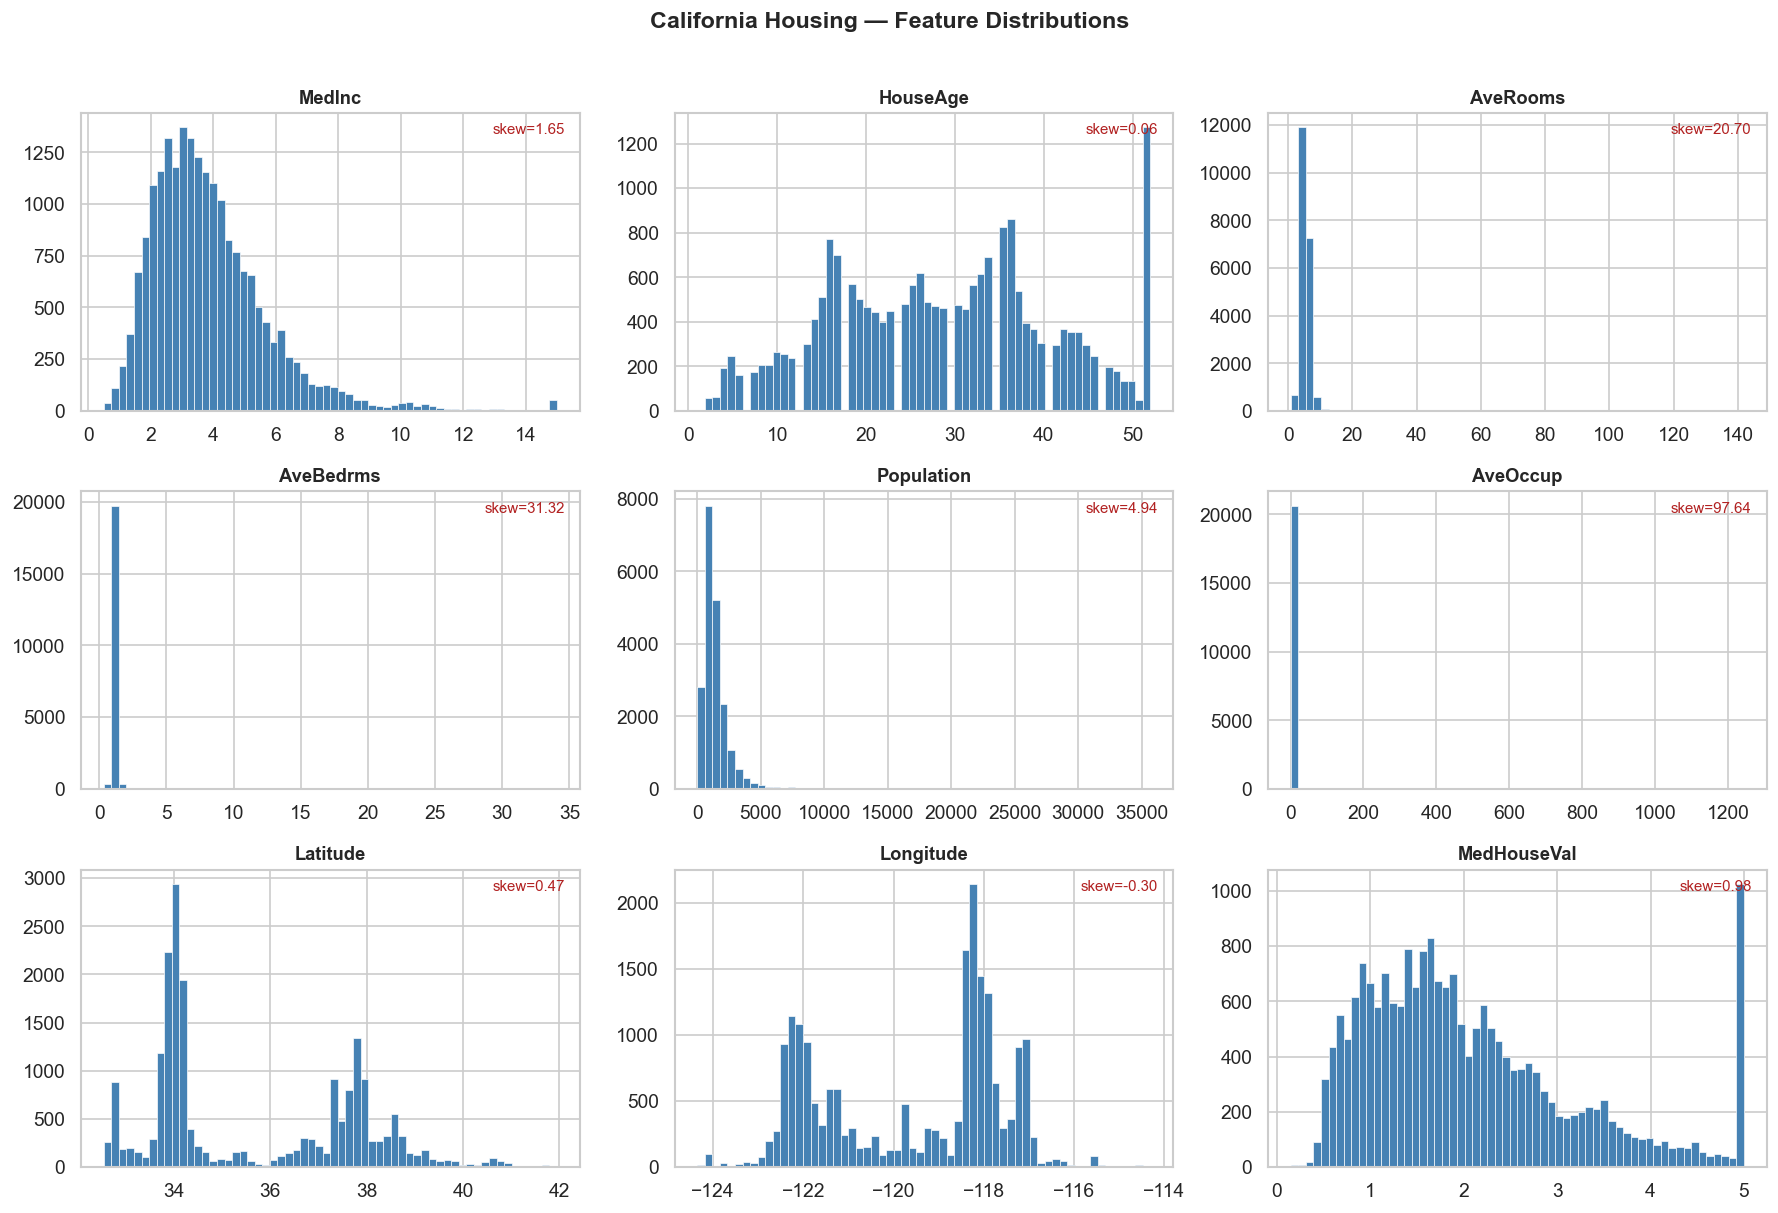


Key observation: AveOccup has extreme outliers (census block errors):
count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64
Max AveOccup: 1243.3 — physically impossible


In [4]:
# ---- 1.2 Feature Distributions ----
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), df_raw.columns):
    ax.hist(df_raw[col], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    # Annotate skewness
    skew = df_raw[col].skew()
    ax.annotate(f'skew={skew:.2f}', xy=(0.97, 0.93), xycoords='axes fraction',
                ha='right', fontsize=9, color='firebrick')

plt.suptitle('California Housing — Feature Distributions', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Observations:
# - MedInc: right-skewed (long tail of high earners)
# - AveRooms, AveBedrms, Population, AveOccup: VERY right-skewed with extreme outliers
# - MedHouseVal: right-skewed AND capped at 5.0 ($500K) — a data truncation artifact
print("\nKey observation: AveOccup has extreme outliers (census block errors):")
print(df_raw['AveOccup'].describe())
print(f"Max AveOccup: {df_raw['AveOccup'].max():.1f} — physically impossible")

In [5]:
# ── 1.3 IQR Outlier Check ─────────────────────────────────────────────────────
#
# IQR method: flag values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
# Why IQR over Z-score? IQR is non-parametric — works on skewed distributions.
# Z-score assumes normality which most of these features violate.
#
Q1 = df_raw.quantile(0.25)
Q3 = df_raw.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outlier_counts = ((df_raw < lower_fence) | (df_raw > upper_fence)).sum()
outlier_pct    = (outlier_counts / len(df_raw) * 100).round(2)

print('IQR Outlier Report (for reference only — high counts do NOT mean remove):')
print(pd.DataFrame({'Count': outlier_counts, 'Percent(%)': outlier_pct}).to_string())
print(f'\nRows with ANY outlier column: {((df_raw < lower_fence) | (df_raw > upper_fence)).any(axis=1).sum()}')

# ── REMOVAL POLICY: physically impossible values only ─────────────────────────
#
# High IQR counts in AveBedrms (6.9%) and Population (5.8%) do NOT mean those
# rows are corrupt. They reflect real skewed distributions in California housing:
#   - AveBedrms: narrow IQR (1.01–1.10) means anything slightly unusual trips the fence
#   - Population: dense urban blocks are genuinely large — real signal, not noise
#   - MedInc: wealthy areas genuinely exist — Beverly Hills, Palo Alto etc.
#   - MedHouseVal: the target — never remove rows based on the target
#
# We only remove rows where the value is PHYSICALLY IMPOSSIBLE:
#
#   AveOccup  > 50  : max is 1,243 people/household — census data entry error
#                     (US avg household size < 3; >50 cannot be real)
#
#   AveRooms  > 50  : max is 141.9 rooms/household average — impossible
#                     (even large apartment blocks average <20 rooms per unit)
#
#   AveBedrms > 20  : max is 34.1 bedrooms/household average — impossible
#                     (high IQR count here is a tight-fence artifact, not real outliers;
#                      but values > 20 are genuine errors)
#
# Thresholds are domain-knowledge driven, not statistical. Each removes < 10 rows.
#
before = len(df_raw)

df = df_raw[
    (df_raw['AveOccup']  < 50) &
    (df_raw['AveRooms']  < 50) &
    (df_raw['AveBedrms'] < 20)
].copy()

removed_occup   = (df_raw['AveOccup']  >= 50).sum()
removed_rooms   = (df_raw['AveRooms']  >= 50).sum()
removed_bedrms  = (df_raw['AveBedrms'] >= 20).sum()
removed_total   = before - len(df)

print(f'\n── Rows removed by filter ───────────────────────────')
print(f'  AveOccup  >= 50  : {removed_occup:>4} rows')
print(f'  AveRooms  >= 50  : {removed_rooms:>4} rows')
print(f'  AveBedrms >= 20  : {removed_bedrms:>4} rows')
print(f'  Total removed    : {removed_total:>4} rows  ({removed_total/before*100:.2f}% of dataset)')
print(f'  Remaining        : {len(df):>5} rows')
print(f'\nAll remaining IQR-flagged rows are KEPT — they are real, skewed-but-valid data.')
print(f'Skew in AveBedrms/Population/MedInc will be handled by:')
print(f'  - log1p transforms (log_population, log_ave_occup) in the feature engineering step')
print(f'  - bedroom_ratio feature (de-correlates AveRooms & AveBedrms)')
print(f'  - StandardScaler (reduces leverage of large values after log compression)')


IQR Outlier Report (for reference only — high counts do NOT mean remove):
             Count  Percent(%)
MedInc         681        3.30
HouseAge         0        0.00
AveRooms       511        2.48
AveBedrms     1424        6.90
Population    1196        5.79
AveOccup       711        3.44
Latitude         0        0.00
Longitude        0        0.00
MedHouseVal   1071        5.19

Rows with ANY outlier column: 4328

── Rows removed by filter ───────────────────────────
  AveOccup  >= 50  :    7 rows
  AveRooms  >= 50  :    9 rows
  AveBedrms >= 20  :    2 rows
  Total removed    :   16 rows  (0.08% of dataset)
  Remaining        : 20624 rows

All remaining IQR-flagged rows are KEPT — they are real, skewed-but-valid data.
Skew in AveBedrms/Population/MedInc will be handled by:
  - log1p transforms (log_population, log_ave_occup) in the feature engineering step
  - bedroom_ratio feature (de-correlates AveRooms & AveBedrms)
  - StandardScaler (reduces leverage of large values after log c

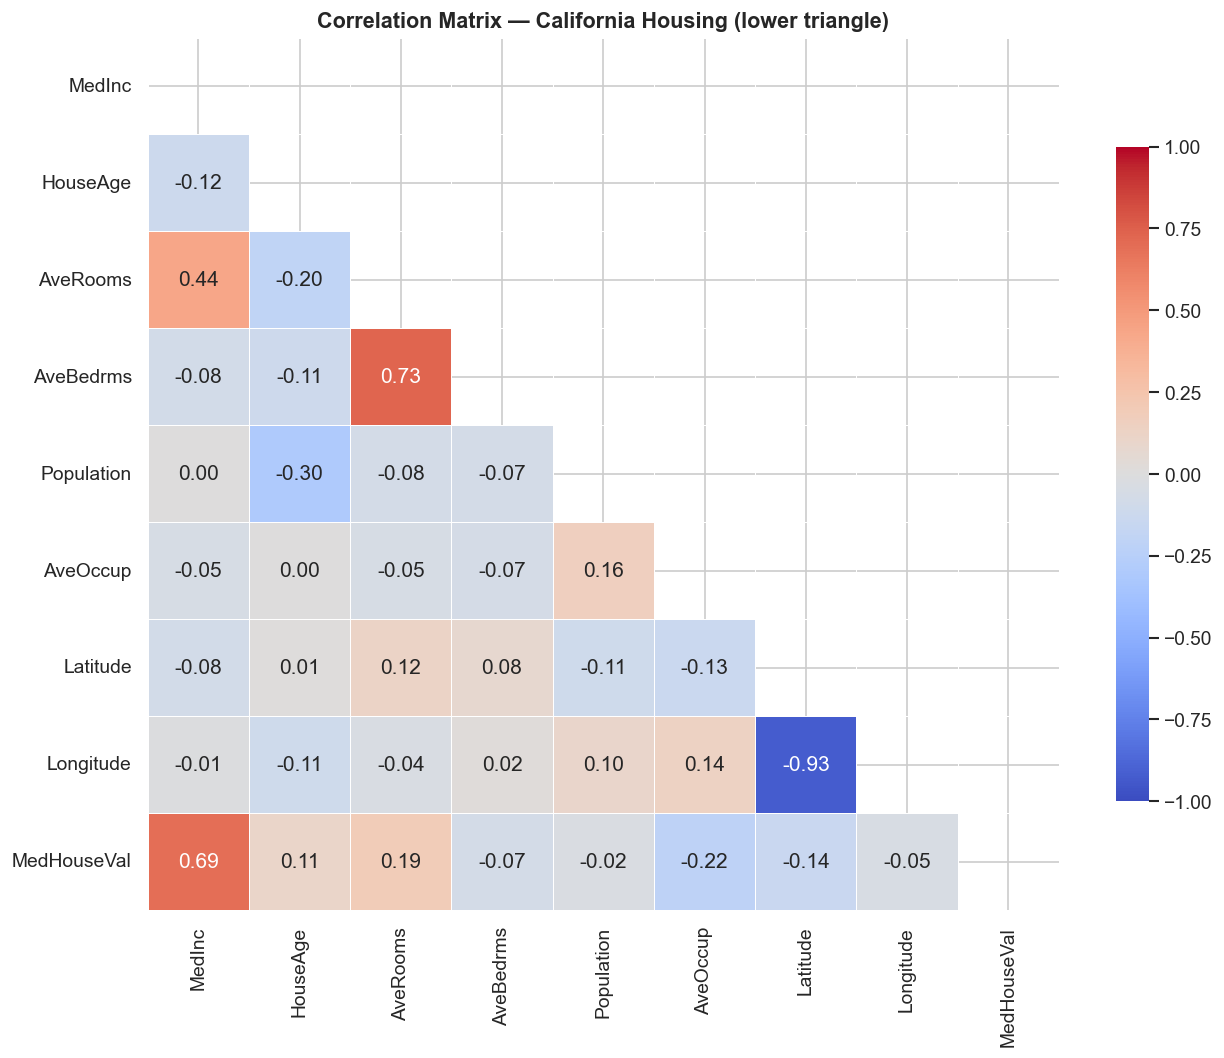

Feature correlations with target (MedHouseVal):
MedInc        0.689
AveOccup     -0.216
AveRooms      0.194
Latitude     -0.144
HouseAge      0.106
AveBedrms    -0.073
Longitude    -0.046
Population   -0.025

Insight: AveRooms and AveBedrms highly correlated (0.73) → bedroom_ratio will de-correlate these


In [38]:
# ── 1.4 Correlation Heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.75}
)
ax.set_title('Correlation Matrix — California Housing (lower triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Key observations printed:
target_corr = corr['MedHouseVal'].drop('MedHouseVal').sort_values(key=abs, ascending=False)
print('Feature correlations with target (MedHouseVal):')
print(target_corr.round(3).to_string())
print('\nInsight: AveRooms and AveBedrms highly correlated (0.73) → bedroom_ratio will de-correlate these')

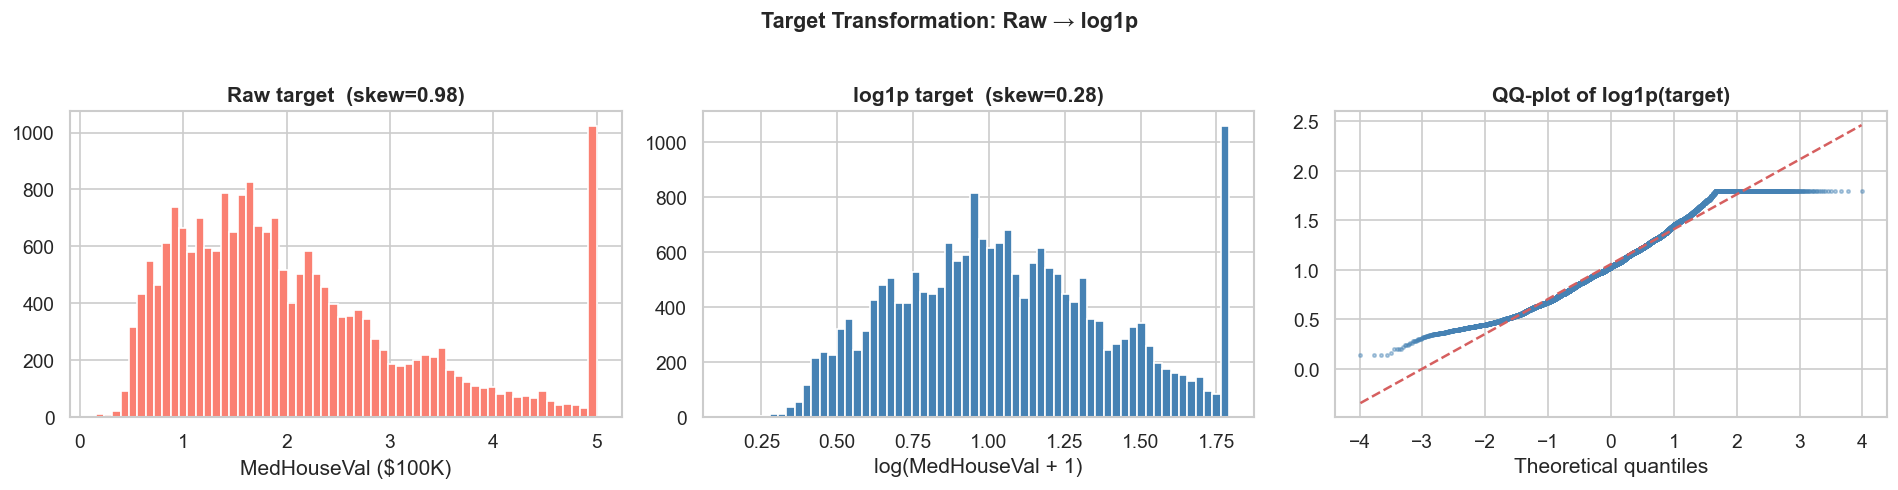

Raw  skewness: 0.9775
Log1p skewness: 0.2757  ← much closer to 0 (symmetric)


In [7]:
# ── 1.5 Log-Transform Target + Visualise ──────────────────────────────────────
#
# WHY log1p(y)?
# 1. MedHouseVal is right-skewed (skew ≈ 0.98) — log compresses the long tail
# 2. The $500K cap causes a spike at the right end — log softens this
# 3. OLS assumes homoscedastic errors: Var(ε) = constant.
#    With skewed y, variance of residuals GROWS with y → violates this.
#    After log-transform, variance is much more stable across the range.
# 4. Back-transform with np.expm1(pred) after prediction.
#
X = df.drop(columns=['MedHouseVal'])
y_raw = df['MedHouseVal']
y = np.log1p(y_raw)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_raw, bins=60, color='salmon', edgecolor='white')
axes[0].set_title(f'Raw target  (skew={y_raw.skew():.2f})', fontweight='bold')
axes[0].set_xlabel('MedHouseVal ($100K)')

axes[1].hist(y, bins=60, color='steelblue', edgecolor='white')
axes[1].set_title(f'log1p target  (skew={y.skew():.2f})', fontweight='bold')
axes[1].set_xlabel('log(MedHouseVal + 1)')

# QQ-plot of transformed target
(osm, osr), (sl, ic, _) = stats.probplot(y, dist='norm')
axes[2].scatter(osm, osr, s=4, alpha=0.4, color='steelblue')
axes[2].plot(osm, sl*osm+ic, 'r--', linewidth=1.5)
axes[2].set_title('QQ-plot of log1p(target)', fontweight='bold')
axes[2].set_xlabel('Theoretical quantiles')

plt.suptitle('Target Transformation: Raw → log1p', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_target_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Raw  skewness: {y_raw.skew():.4f}')
print(f'Log1p skewness: {y.skew():.4f}  ← much closer to 0 (symmetric)')

In [8]:
# ── 1.6 80/20 Train/Test Split ────────────────────────────────────────────────
#
# random_state=42 for reproducibility.
# We do NOT stratify — this is a regression problem (continuous target).
# All scalers and transformers will be fit on X_train ONLY.
#
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'y_train mean: {y_train.mean():.4f}  |  y_test mean: {y_test.mean():.4f}  (should be close)')

# Baseline: simple scaler for Prompt 2 (no feature engineering)
# Used in the plain regularisation comparison
scaler_baseline = StandardScaler()
X_train_sc = scaler_baseline.fit_transform(X_train)
X_test_sc  = scaler_baseline.transform(X_test)

Train: (16499, 8)  |  Test: (4125, 8)
y_train mean: 1.0579  |  y_test mean: 1.0493  (should be close)


# **Feature Engineering Pipeline**

In [9]:
# ── 2.1 Custom Feature Engineering Transformer ────────────────────────────────
#
# Inherits from BaseEstimator + TransformerMixin so it works inside sklearn Pipelines.
# fit() learns the KMeans spatial clusters on training lat/lon.
# transform() applies all engineered features to any split.
#
class CaliforniaFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Custom feature engineering transformer for California Housing.
    
    Adds:
        - bedroom_ratio    : AveBedrms / AveRooms
        - rooms_per_person : AveRooms / AveOccup
        - income_rooms     : MedInc * AveRooms (explicit interaction)
        - dist_to_LA       : Euclidean distance to Los Angeles
        - dist_to_SF       : Euclidean distance to San Francisco
        - log_population   : log1p(Population)
        - log_ave_occup    : log1p(AveOccup)
        - geo_cluster      : KMeans spatial cluster ID (string → OHE downstream)
    """
    
    # Major California economic hub coordinates
    LA_LAT, LA_LON = 34.0522, -118.2437
    SF_LAT, SF_LON = 37.7749, -122.4194

    def __init__(self, n_clusters: int = 12, random_state: int = 42):
        self.n_clusters   = n_clusters
        self.random_state = random_state

    def fit(self, X: pd.DataFrame, y=None):
        # ONLY the KMeans needs to be fitted — everything else is deterministic math
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=10
        )
        self.kmeans_.fit(X[['Latitude', 'Longitude']])
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_out = X.copy()

        # --- Ratio features (de-correlate AveRooms & AveBedrms) ---
        X_out['bedroom_ratio']    = X_out['AveBedrms'] / X_out['AveRooms'].clip(lower=1e-3)
        X_out['rooms_per_person'] = X_out['AveRooms']  / X_out['AveOccup'].clip(lower=1e-3)

        # --- Explicit interaction (income × space) ---
        X_out['income_rooms'] = X_out['MedInc'] * X_out['AveRooms']

        # --- Geographic distance features ---
        X_out['dist_to_LA'] = np.sqrt(
            (X_out['Latitude']  - self.LA_LAT)**2 +
            (X_out['Longitude'] - self.LA_LON)**2
        )
        X_out['dist_to_SF'] = np.sqrt(
            (X_out['Latitude']  - self.SF_LAT)**2 +
            (X_out['Longitude'] - self.SF_LON)**2
        )

        # --- Log-compressed skewed features ---
        X_out['log_population'] = np.log1p(X_out['Population'])
        X_out['log_ave_occup']  = np.log1p(X_out['AveOccup'])

        # --- Spatial cluster (fit on training data only → no leakage) ---
        X_out['geo_cluster'] = self.kmeans_.predict(
            X_out[['Latitude', 'Longitude']]
        ).astype(str)

        return X_out

print('CaliforniaFeatureEngineer class defined ✓')

CaliforniaFeatureEngineer class defined ✓


In [10]:
# ── 2.2 Build the Full Preprocessing Pipeline ─────────────────────────────────
#
# Pipeline order (prevents leakage at every step):
#   1. CaliforniaFeatureEngineer  → adds 8 new columns (including geo_cluster string)
#   2. ColumnTransformer splits the result into:
#        numeric_features  → StandardScaler (fit on train only)
#        categorical_features → OneHotEncoder(drop='first') — removes 1 dummy to avoid
#                               perfect multicollinearity (dummy variable trap)
#
# Note: PolynomialFeatures is NOT applied in the main pipeline here.
# For Prompt 2 models (plain regularisation), we use this pipeline as-is.
# For Prompt 4 (Poly+Ridge), we add PolynomialFeatures inside a separate pipeline.
#

NUMERIC_FEATURES = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
    'Latitude', 'Longitude',
    # Engineered
    'bedroom_ratio', 'rooms_per_person', 'income_rooms',
    'dist_to_LA', 'dist_to_SF',
    'log_population', 'log_ave_occup'
]
CATEGORICAL_FEATURES = ['geo_cluster']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
         CATEGORICAL_FEATURES)
    ],
    remainder='drop'   # safety: drop any unexpected columns
)

feature_pipeline = Pipeline([
    ('engineer',    CaliforniaFeatureEngineer(n_clusters=12, random_state=RANDOM_STATE)),
    ('preprocessor', preprocessor)
])

# Fit on train ONLY — then transform both splits
X_train_fe = feature_pipeline.fit_transform(X_train)
X_test_fe  = feature_pipeline.transform(X_test)

n_numeric_out = len(NUMERIC_FEATURES)
n_cat_out     = X_train_fe.shape[1] - n_numeric_out
print(f'Original features     : {X_train.shape[1]}')
print(f'After engineering     : {n_numeric_out} numeric + {n_cat_out} OHE cat = {X_train_fe.shape[1]} total')
print(f'Shape X_train_fe      : {X_train_fe.shape}')
print(f'Shape X_test_fe       : {X_test_fe.shape}')

Original features     : 8
After engineering     : 15 numeric + 11 OHE cat = 26 total
Shape X_train_fe      : (16499, 26)
Shape X_test_fe       : (4125, 26)


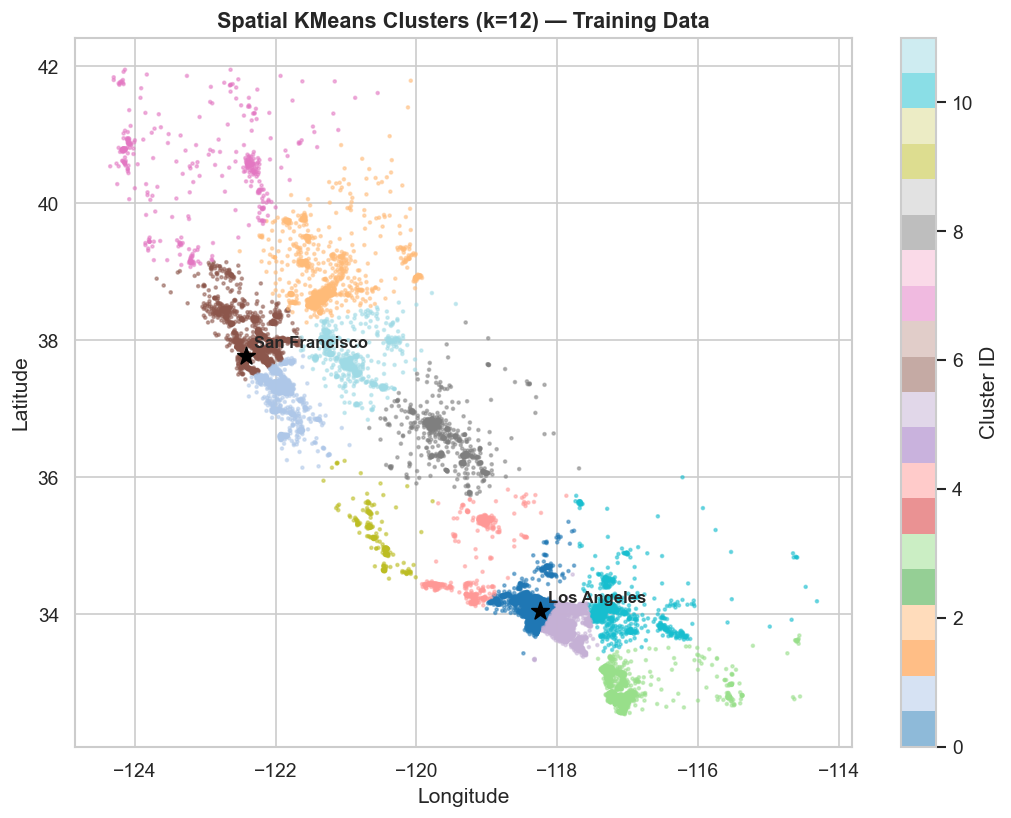

Clusters should show distinct geographic zones (Bay Area, LA basin, Central Valley, etc.)


In [11]:
# ── 2.3 Visualise Geo Clusters ────────────────────────────────────────────────
# Quick sanity check: do the 12 clusters make geographic sense?

engineer_step = feature_pipeline.named_steps['engineer']
cluster_labels = engineer_step.kmeans_.predict(X_train[['Latitude', 'Longitude']])

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    X_train['Longitude'], X_train['Latitude'],
    c=cluster_labels, cmap='tab20', s=3, alpha=0.5
)
# Mark hub cities
ax.scatter([-118.2437, -122.4194], [34.0522, 37.7749],
           c='black', s=120, zorder=5, marker='*')
ax.annotate('Los Angeles', (-118.2437, 34.0522), textcoords='offset points',
            xytext=(5, 5), fontsize=10, fontweight='bold')
ax.annotate('San Francisco', (-122.4194, 37.7749), textcoords='offset points',
            xytext=(5, 5), fontsize=10, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster ID')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial KMeans Clusters (k=12) — Training Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_geo_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print('Clusters should show distinct geographic zones (Bay Area, LA basin, Central Valley, etc.)')

# **OLS/ Ridge/ Lasso/ ElasticNet + Lasso Coefficient Path**

In [12]:
# ── 3.1 Model Evaluation Helper ───────────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, label=''):
    """
    Fit model, predict, back-transform from log-space, compute RMSE/MAE/R².
    RMSE and MAE are in raw $100K units (same as raw MedHouseVal column).
    Multiply by 100_000 to get USD.
    """
    model.fit(X_tr, y_tr)
    pred_log  = model.predict(X_te)
    pred_orig = np.expm1(pred_log)
    y_te_orig = np.expm1(y_te.values)

    rmse = np.sqrt(mean_squared_error(y_te_orig * 100_000, pred_orig * 100_000)) 
    mae  = mean_absolute_error(y_te_orig* 100_000, pred_orig* 100_000) 
    r2   = r2_score(y_te_orig, pred_orig)

    # If model has alpha_ attribute, report it
    alpha_str = ''
    if hasattr(model, 'alpha_'):
        alpha_str = f'{model.alpha_:.5f}'

    return {
        'Model': name, 'Input': label,
        'RMSE ($)': f'{rmse:,.0f}',
        'MAE ($)' : f'{mae:,.0f}',
        'R²'      : f'{r2:.4f}',
        'Best α'  : alpha_str
    }

alphas = np.logspace(-4, 3, 200)   # search space for RidgeCV / LassoCV

print('Helper functions defined ✓')

Helper functions defined ✓


In [13]:
# ── 3.2 Fit & Compare Models — Baseline vs Engineered ─────────────────────────
model_configs = [
    ('OLS',        LinearRegression()),
    ('Ridge',      RidgeCV(alphas=alphas, cv=5)),
    ('Lasso',      LassoCV(alphas=alphas, cv=5, max_iter=15000, random_state=RANDOM_STATE)),
    ('ElasticNet', ElasticNetCV(
                        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                        alphas=alphas, cv=5, max_iter=15000,
                        random_state=RANDOM_STATE)),
]

results_baseline  = []
results_engineered = []

# Store fitted models for later plots
fitted_models_baseline   = {}
fitted_models_engineered = {}

for name, model_b in model_configs:
    # Baseline
    import copy
    model_b2 = copy.deepcopy(model_b)
    r = evaluate_model(name, model_b2, X_train_sc, y_train, X_test_sc, y_test, label='Baseline')
    results_baseline.append(r)
    fitted_models_baseline[name] = model_b2

    # Engineered
    model_e = copy.deepcopy(model_b)
    r2e = evaluate_model(name, model_e, X_train_fe, y_train, X_test_fe, y_test, label='Engineered')
    results_engineered.append(r2e)
    fitted_models_engineered[name] = model_e

print('=== BASELINE (StandardScaler only, 8 features) ===')
print(pd.DataFrame(results_baseline)[['Model','RMSE ($)','MAE ($)','R²','Best α']].to_string(index=False))
print()
print('=== ENGINEERED (15 numeric + geo OHE clusters) ===')
print(pd.DataFrame(results_engineered)[['Model','RMSE ($)','MAE ($)','R²','Best α']].to_string(index=False))

=== BASELINE (StandardScaler only, 8 features) ===
     Model RMSE ($) MAE ($)     R²  Best α
       OLS   73,912  49,821 0.5865        
     Ridge   73,941  49,833 0.5862 6.59319
     Lasso   73,897  49,850 0.5867 0.00026
ElasticNet   73,899  49,850 0.5867 0.00029

=== ENGINEERED (15 numeric + geo OHE clusters) ===
     Model RMSE ($) MAE ($)     R²  Best α
       OLS   69,938  44,552 0.6298        
     Ridge   70,443  44,569 0.6244 3.44896
     Lasso   70,695  44,593 0.6217 0.00010
ElasticNet   70,276  44,561 0.6262 0.00011


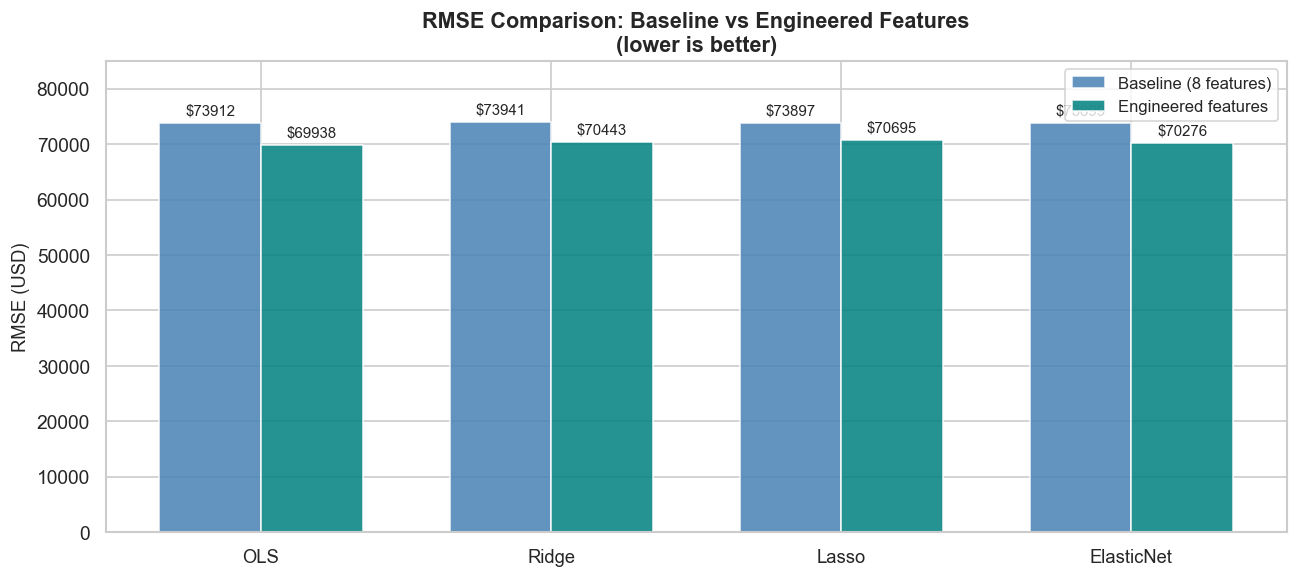

In [14]:
# ── 3.3 RMSE Comparison Bar Chart ─────────────────────────────────────────────
model_names = [r['Model'] for r in results_baseline]
rmse_base   = [float(r['RMSE ($)'].replace(',','')) for r in results_baseline]
rmse_eng    = [float(r['RMSE ($)'].replace(',','')) for r in results_engineered]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, rmse_base, width, label='Baseline (8 features)',
               color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, rmse_eng,  width, label='Engineered features',
               color='teal',      alpha=0.85, edgecolor='white')

ax.bar_label(bars1, fmt='$%.0f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='$%.0f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('RMSE (USD)', fontsize=11)
ax.set_title('RMSE Comparison: Baseline vs Engineered Features\n(lower is better)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, max(rmse_base) * 1.15)
plt.tight_layout()
plt.savefig('05_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

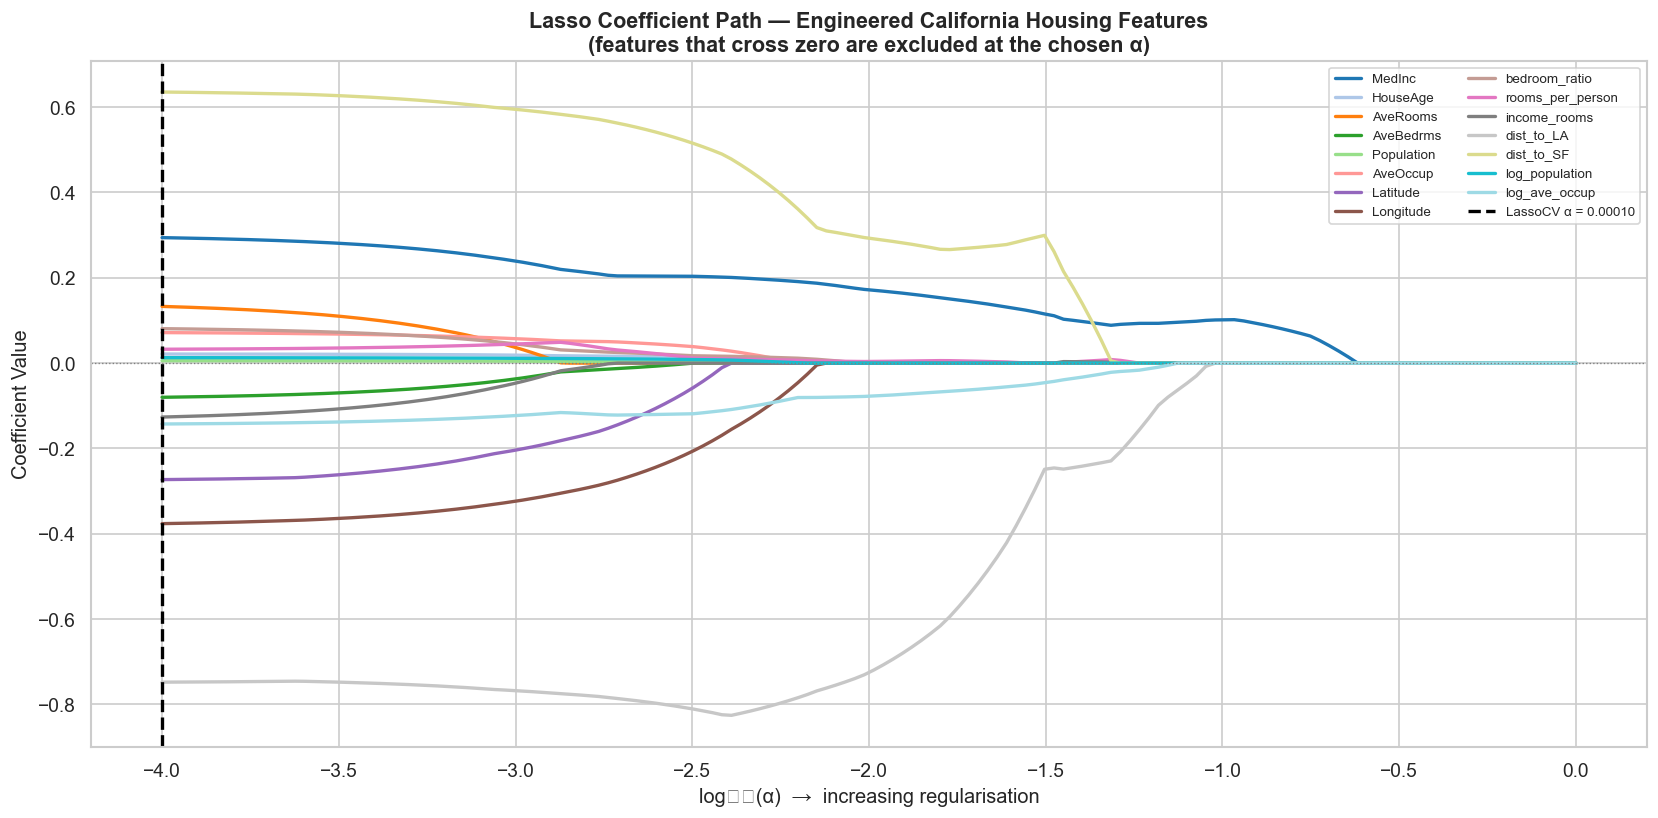

Features zeroed out (1): ['geo_cluster_7']
Active features    (25): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'bedroom_ratio', 'rooms_per_person', 'income_rooms', 'dist_to_LA', 'dist_to_SF', 'log_population', 'log_ave_occup', 'geo_cluster_1', 'geo_cluster_10', 'geo_cluster_11', 'geo_cluster_2', 'geo_cluster_3', 'geo_cluster_4', 'geo_cluster_5', 'geo_cluster_6', 'geo_cluster_8', 'geo_cluster_9']


In [15]:
# ── 3.4 Lasso Coefficient Path (Engineered Features) ─────────────────────────
#
# As alpha (penalty strength) increases:
# - Features with weak predictive power hit zero first
# - Features that survive to large alpha are the strong predictors
# - The vertical dashed line marks the alpha chosen by LassoCV (5-fold CV)
#
# We build feature names from the ColumnTransformer to label the path.

# Get feature names from the preprocessor
ct = feature_pipeline.named_steps['preprocessor']
cat_feature_names = ct.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
all_feature_names = NUMERIC_FEATURES + list(cat_feature_names)

# Compute Lasso path on the engineered training data
path_alphas = np.logspace(-4, 0, 150)
alphas_path, coefs_path, _ = lasso_path(
    X_train_fe, y_train,
    alphas=path_alphas,
    max_iter=10000
)

# Best alpha from the fitted LassoCV model
lasso_best_alpha = fitted_models_engineered['Lasso'].alpha_

# Plot: show only numeric features for clarity (15 lines vs 26+)
n_numeric = len(NUMERIC_FEATURES)
fig, ax = plt.subplots(figsize=(14, 7))

cmap   = plt.cm.tab20
colors = cmap(np.linspace(0, 1, n_numeric))

for i, (feat, color) in enumerate(zip(NUMERIC_FEATURES, colors)):
    ax.plot(np.log10(alphas_path), coefs_path[i],
            label=feat, color=color, linewidth=2)

ax.axvline(np.log10(lasso_best_alpha), color='black', linestyle='--',
           linewidth=2, label=f'LassoCV α = {lasso_best_alpha:.5f}')
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')

ax.set_xlabel('log₁₀(α)  →  increasing regularisation', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Lasso Coefficient Path — Engineered California Housing Features\n'
             '(features that cross zero are excluded at the chosen α)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('06_lasso_coefficient_path.png', dpi=150, bbox_inches='tight')
plt.show()

# Print zeroed features
lasso_coefs = fitted_models_engineered['Lasso'].coef_
zeroed = [name for name, coef in zip(all_feature_names, lasso_coefs) if coef == 0.0]
active = [name for name, coef in zip(all_feature_names, lasso_coefs) if coef != 0.0]
print(f'Features zeroed out ({len(zeroed)}): {zeroed}')
print(f'Active features    ({len(active)}): {active}')

# **BayesianRidge Prediction Intervals and Empirical Coverage**

In [16]:
# ── 4.1 Fit BayesianRidge on Engineered Features ─────────────────────────────
br = BayesianRidge(max_iter=500, tol=1e-6, compute_score=True)
br.fit(X_train_fe, y_train)

y_pred_log, y_std_log = br.predict(X_test_fe, return_std=True)

# Back-transform predictions to original scale ($100K)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test.values)

# Delta method: propagate log-space std to original scale
# Approximation: σ_orig ≈ σ_log × exp(μ_log)
# Valid when σ_log is small relative to μ_log (which it is here)
y_std = y_std_log * np.exp(y_pred_log)

# 95% Prediction Interval
lower = y_pred - 1.96 * y_std
upper = y_pred + 1.96 * y_std

# Empirical Coverage
inside      = (y_true >= lower) & (y_true <= upper)
coverage    = inside.mean()
br_rmse     = np.sqrt(mean_squared_error(y_true, y_pred)) * 100_000
br_mae      = mean_absolute_error(y_true, y_pred)          * 100_000

print(f'BayesianRidge RMSE     : ${br_rmse:,.0f}')
print(f'BayesianRidge MAE      : ${br_mae:,.0f}')
print(f'Empirical 95% Coverage : {coverage:.3f}  ({coverage*100:.1f}%)')
print(f'Expected               : ~0.950 (95.0%)')

# Add to results
results_engineered.append({
    'Model': 'BayesianRidge', 'Input': 'Engineered',
    'RMSE ($)': f'{br_rmse:,.0f}', 'MAE ($)': f'{br_mae:,.0f}',
    'R²': f'{r2_score(y_true, y_pred):.4f}', 'Best α': 'auto'
})

BayesianRidge RMSE     : $70,169
BayesianRidge MAE      : $44,559
Empirical 95% Coverage : 0.938  (93.8%)
Expected               : ~0.950 (95.0%)


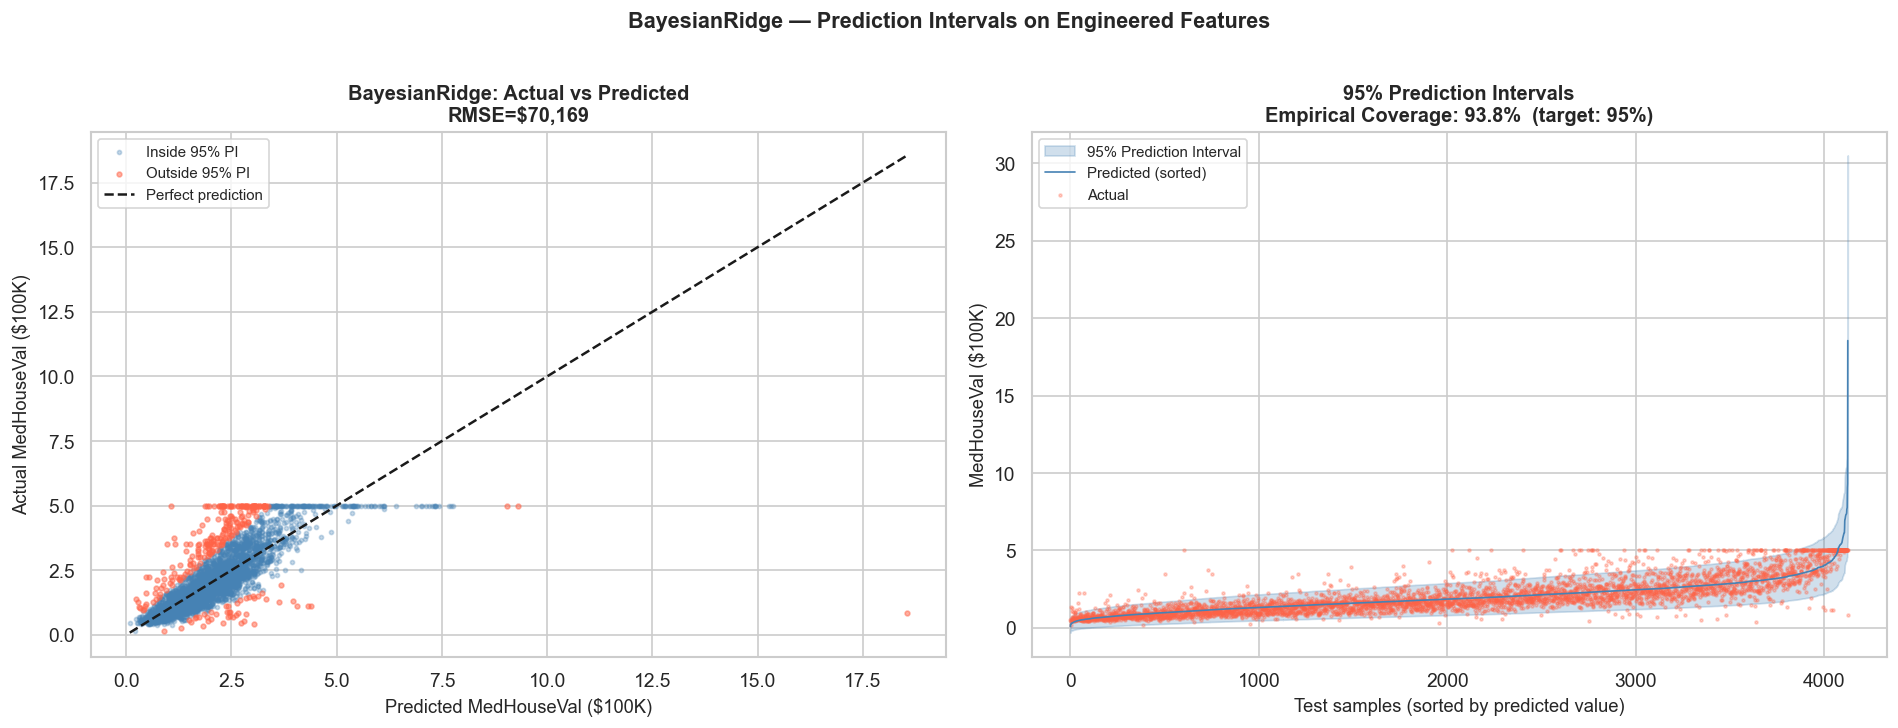

In [17]:
# ── 4.2 Plots: Actual vs Predicted + Prediction Interval Ribbon ───────────────
sort_idx  = np.argsort(y_pred)
y_pred_s  = y_pred[sort_idx]
y_true_s  = y_true[sort_idx]
lower_s   = lower[sort_idx]
upper_s   = upper[sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Scatter — actual vs predicted ---
ax = axes[0]
# Colour-code by whether inside or outside the PI
ax.scatter(y_pred[inside],  y_true[inside],  alpha=0.3, s=6, color='steelblue', label='Inside 95% PI')
ax.scatter(y_pred[~inside], y_true[~inside], alpha=0.5, s=8, color='tomato',    label='Outside 95% PI')
mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Predicted MedHouseVal ($100K)', fontsize=11)
ax.set_ylabel('Actual MedHouseVal ($100K)',    fontsize=11)
ax.set_title(f'BayesianRidge: Actual vs Predicted\nRMSE=${br_rmse:,.0f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# --- Panel 2: Sorted ribbon plot ---
ax = axes[1]
x_idx = np.arange(len(y_pred_s))
ax.fill_between(x_idx, lower_s, upper_s, alpha=0.25, color='steelblue', label='95% Prediction Interval')
ax.plot(x_idx, y_pred_s, color='steelblue', linewidth=1, label='Predicted (sorted)')
ax.scatter(x_idx, y_true_s, s=3, color='tomato', alpha=0.3, label='Actual')
ax.set_xlabel('Test samples (sorted by predicted value)', fontsize=11)
ax.set_ylabel('MedHouseVal ($100K)', fontsize=11)
ax.set_title(f'95% Prediction Intervals\nEmpirical Coverage: {coverage:.1%}  (target: 95%)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('BayesianRidge — Prediction Intervals on Engineered Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('07_bayesian_ridge_pi.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── 4.3 Coverage by Prediction Decile ─────────────────────────────────────────
# Checks if miscalibration is concentrated in a specific price range
decile_labels = pd.qcut(y_pred, q=10, labels=False)
coverage_by_decile = pd.Series(inside).groupby(decile_labels).agg(['mean', 'count'])
coverage_by_decile.columns = ['Coverage', 'N samples']
coverage_by_decile.index.name = 'Decile (0=lowest pred)'
print('Coverage by prediction decile (ideal: all rows ≈ 0.95):')
print(coverage_by_decile.round(3).to_string())

Coverage by prediction decile (ideal: all rows ≈ 0.95):
                        Coverage  N samples
Decile (0=lowest pred)                     
0                          0.944        413
1                          0.971        412
2                          0.976        413
3                          0.966        412
4                          0.956        413
5                          0.925        412
6                          0.913        412
7                          0.906        413
8                          0.881        412
9                          0.942        413


# **Polynomial Ridge + Residual Diagnostics**

In [19]:
# ── 5.1 Polynomial + Ridge Pipeline (on engineered numerics + geo OHE) ─────────
#
# Architecture:
#   [CaliforniaFeatureEngineer]
#       → numeric cols: StandardScaler → PolynomialFeatures(degree=2)
#       → geo_cluster: OneHotEncoder(drop='first')
#   → RidgeCV(cv=5)
#

poly_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('scaler', StandardScaler()),
            ('poly',   PolynomialFeatures(degree=2, include_bias=False))
        ]), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
         CATEGORICAL_FEATURES)
    ],
    remainder='drop'
)

poly_ridge_pipeline = Pipeline([
    ('engineer',     CaliforniaFeatureEngineer(n_clusters=12, random_state=RANDOM_STATE)),
    ('preprocessor', poly_preprocessor),
    ('ridge',        RidgeCV(alphas=np.logspace(-3, 4, 200), cv=5))
])

poly_ridge_pipeline.fit(X_train, y_train)   # raw X_train — pipeline handles everything

n_poly_features = poly_ridge_pipeline.named_steps['preprocessor']\
                     .named_transformers_['num']\
                     .named_steps['poly'].n_output_features_
best_poly_alpha = poly_ridge_pipeline.named_steps['ridge'].alpha_

print(f'Numeric polynomial features : {n_poly_features}')
print(f'Ridge best alpha            : {best_poly_alpha:.4f}')

Numeric polynomial features : 135
Ridge best alpha            : 27.0496


In [20]:
# ── 5.2 Predictions & RMSE Comparison ─────────────────────────────────────────
y_pred_poly_log = poly_ridge_pipeline.predict(X_test)
y_pred_poly     = np.expm1(y_pred_poly_log)
y_true_poly     = np.expm1(y_test.values)

rmse_poly = np.sqrt(mean_squared_error(y_true_poly, y_pred_poly)) * 100_000
mae_poly  = mean_absolute_error(y_true_poly, y_pred_poly)          * 100_000
r2_poly   = r2_score(y_true_poly, y_pred_poly)

# Compare to linear Ridge on engineered features (from Section 3)
rmse_linear_ridge = float(results_engineered[1]['RMSE ($)'].replace(',', ''))

print('RMSE Comparison:')
print(f'  Linear Ridge (engineered)  : ${rmse_linear_ridge:,.0f}')
print(f'  Poly(2)+Ridge (engineered) : ${rmse_poly:,.0f}')
print(f'  RMSE reduction             : {(rmse_linear_ridge - rmse_poly) / rmse_linear_ridge * 100:.1f}%')
print(f'  MAE (Poly+Ridge)           : ${mae_poly:,.0f}')
print(f'  R² (Poly+Ridge)            : {r2_poly:.4f}')

results_engineered.append({
    'Model': 'Poly(2)+Ridge', 'Input': 'Engineered',
    'RMSE ($)': f'{rmse_poly:,.0f}', 'MAE ($)': f'{mae_poly:,.0f}',
    'R²': f'{r2_poly:.4f}', 'Best α': f'{best_poly_alpha:.4f}'
})

RMSE Comparison:
  Linear Ridge (engineered)  : $70,443
  Poly(2)+Ridge (engineered) : $56,919
  RMSE reduction             : 19.2%
  MAE (Poly+Ridge)           : $38,688
  R² (Poly+Ridge)            : 0.7548


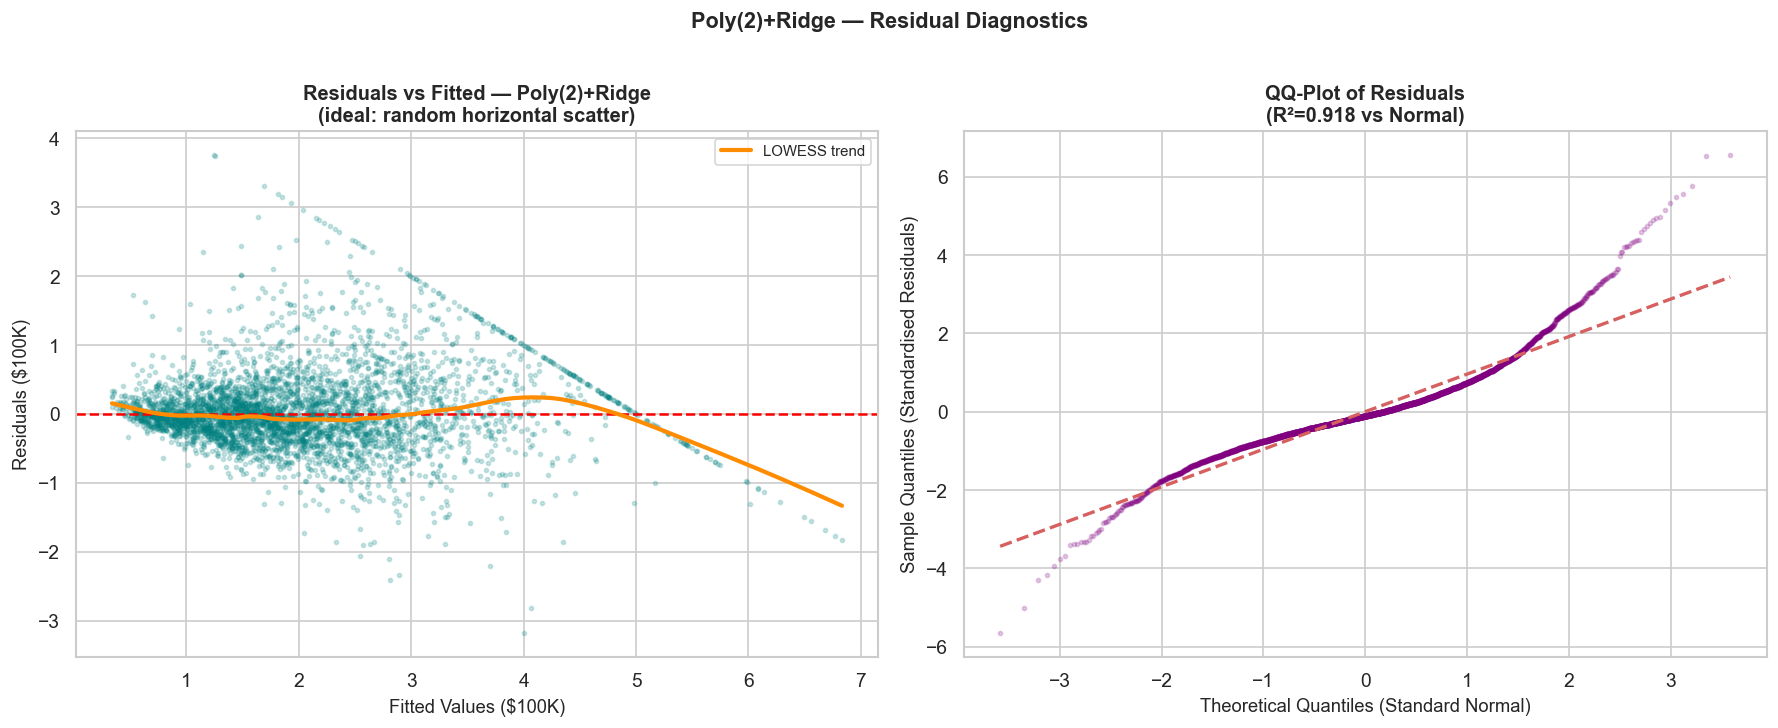

Residual mean  : 0.0  (should be ≈ 0)
Residual std   : 0.6
Residual skew  : 0.987  (should be ≈ 0)
Residual kurt  : 4.972  (should be ≈ 0 for normal)


In [21]:
# ── 5.3 Residual Diagnostics — Residuals vs Fitted & QQ-plot ─────────────────
#
# What we look for:
#
# Residuals vs Fitted:
#   GOOD  → random scatter around zero, constant band width
#   BAD   → funnel shape (heteroscedasticity — variance grows with fitted value)
#   BAD   → U-curve (non-linearity not captured by the model)
#
# QQ-Plot:
#   GOOD  → points follow the diagonal red line
#   BAD   → S-curve (heavy tails — normal distribution assumption violated)
#   BAD   → points above upper-right diagonal (right skew in residuals)
#
# California Housing note: expect mild heavy tails in QQ due to
# the $500K cap in the dataset and true outlier neighbourhoods.

residuals  = y_true_poly - y_pred_poly
fitted_val = y_pred_poly
res_std    = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel 1: Residuals vs Fitted ---
ax = axes[0]
ax.scatter(fitted_val, residuals, alpha=0.2, s=6, color='teal')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)

# Optional LOWESS smooth trend
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    sort_i   = np.argsort(fitted_val)
    smoothed = lowess(residuals[sort_i], fitted_val[sort_i], frac=0.15, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='darkorange', linewidth=2.5, label='LOWESS trend')
    ax.legend(fontsize=9)
except ImportError:
    pass

ax.set_xlabel('Fitted Values ($100K)', fontsize=11)
ax.set_ylabel('Residuals ($100K)', fontsize=11)
ax.set_title('Residuals vs Fitted — Poly(2)+Ridge\n(ideal: random horizontal scatter)',
             fontsize=12, fontweight='bold')

# --- Panel 2: QQ-Plot ---
ax = axes[1]
(osm, osr), (slope, intercept, r_val) = stats.probplot(res_std, dist='norm')
ax.scatter(osm, osr, alpha=0.2, s=6, color='purple')
line_x = np.array([osm.min(), osm.max()])
ax.plot(line_x, slope * line_x + intercept, 'r--', linewidth=2)
ax.set_xlabel('Theoretical Quantiles (Standard Normal)', fontsize=11)
ax.set_ylabel('Sample Quantiles (Standardised Residuals)', fontsize=11)
ax.set_title(f'QQ-Plot of Residuals\n(R²={r_val**2:.3f} vs Normal)',
             fontsize=12, fontweight='bold')

plt.suptitle('Poly(2)+Ridge — Residual Diagnostics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('08_poly_ridge_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Residual statistics
print(f'Residual mean  : {residuals.mean():,.1f}  (should be ≈ 0)')
print(f'Residual std   : {residuals.std():,.1f}')
print(f'Residual skew  : {pd.Series(residuals).skew():.3f}  (should be ≈ 0)')
print(f'Residual kurt  : {pd.Series(residuals).kurtosis():.3f}  (should be ≈ 0 for normal)')

---
## Section 6 — Optuna: Bayesian Hyperparameter Optimisation

### Why Optuna instead of sklearn's CV grid?

| | sklearn RidgeCV / LassoCV | Optuna |
|---|---|---|
| Search strategy | Exhaustive grid over fixed alphas list | Bayesian (TPE) — learns which regions are promising |
| Multi-param models | Poor (ElasticNet grid grows as alpha × l1_ratio) | Natural — handles any number of params |
| Early stopping | None | Prunes unpromising trials mid-run |
| Result | Best value in your predefined list | Can find values *between* grid points |

**TPE (Tree-structured Parzen Estimator):** Optuna builds a probabilistic model of which
hyperparameter values produced good results so far, then samples new trials from the
promising region. After ~20 trials it converges much faster than a 200-point grid.

### What we tune per model
| Model | Parameters | Search space |
|---|---|---|
| Ridge | `alpha` | log-uniform [1e-4, 1e3] |
| Lasso | `alpha` | log-uniform [1e-4, 1e1] |
| ElasticNet | `alpha`, `l1_ratio` | log-uniform × uniform [0.01, 0.99] |
| BayesianRidge | `alpha_1`, `alpha_2`, `lambda_1`, `lambda_2` | log-uniform [1e-7, 1e-1] each |

> Each trial is a 5-fold CV on the training set. The objective is minimise CV RMSE (log-space).
> We use `optuna.samplers.TPESampler` with a fixed seed for reproducibility.


In [39]:
# ── 6.1 Optuna Imports & Global Config ───────────────────────────────────────
import optuna
from optuna.samplers import TPESampler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial noise

N_TRIALS = 80    # sufficient for TPE to converge; increase to 150 for production
CV_FOLDS = 5
OPT_SEED = RANDOM_STATE

def cv_rmse(model, X, y, cv=CV_FOLDS):
    """
    Returns mean CV RMSE in log-space (y is already log1p-transformed).
    Minimising in log-space == minimising RMSE on back-transformed predictions
    because expm1 is monotonic.
    cross_val_score returns negative scores; we negate to get positive RMSE.
    """
    scores = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()

print(f'{N_TRIALS} trials x {CV_FOLDS}-fold CV per model')


80 trials x 5-fold CV per model


In [24]:
# ── 6.2 Tune Ridge ────────────────────────────────────────────────────────────
#
# One hyperparameter: alpha (L2 penalty strength).
# Log-uniform search: equally likely to try 0.001 as 10 or 100 — appropriate
# because alpha spans several orders of magnitude in effect.
#
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e3, log=True)
    return cv_rmse(Ridge(alpha=alpha), X_train_fe, y_train)

study_ridge = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=OPT_SEED),
    study_name='ridge'
)
study_ridge.optimize(objective_ridge, n_trials=N_TRIALS, show_progress_bar=True)

best_ridge_alpha = study_ridge.best_params['alpha']
print(f'Ridge  best alpha         : {best_ridge_alpha:.6f}')
print(f'Ridge  best CV RMSE (log) : {study_ridge.best_value:.6f}')

ridge_opt = Ridge(alpha=best_ridge_alpha)
ridge_opt.fit(X_train_fe, y_train)


Best trial: 33. Best value: 0.185132: 100%|██████████| 80/80 [00:35<00:00,  2.27it/s]

Ridge  best alpha         : 3.272904
Ridge  best CV RMSE (log) : 0.185132


,alpha,3.272904207917852
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [25]:
# ── 6.3 Tune Lasso ────────────────────────────────────────────────────────────
#
# Upper bound 1e1 (not 1e3): at large alpha, Lasso zeros all coefficients.
# max_iter=15000 prevents convergence warnings on the engineered feature matrix.
#
def objective_lasso(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e1, log=True)
    return cv_rmse(Lasso(alpha=alpha, max_iter=15000), X_train_fe, y_train)

study_lasso = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=OPT_SEED),
    study_name='lasso'
)
study_lasso.optimize(objective_lasso, n_trials=N_TRIALS, show_progress_bar=True)

best_lasso_alpha = study_lasso.best_params['alpha']
print(f'Lasso  best alpha         : {best_lasso_alpha:.6f}')
print(f'Lasso  best CV RMSE (log) : {study_lasso.best_value:.6f}')

lasso_opt = Lasso(alpha=best_lasso_alpha, max_iter=15000)
lasso_opt.fit(X_train_fe, y_train)

# Show which features are zeroed at the Optuna-chosen alpha
ct_step = feature_pipeline.named_steps['preprocessor']
cat_names_opt = ct_step.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
all_feat_names_opt = NUMERIC_FEATURES + list(cat_names_opt)
zeroed = [n for n, c in zip(all_feat_names_opt, lasso_opt.coef_) if c == 0.0]
print(f'Features zeroed by Optuna Lasso ({len(zeroed)}): {zeroed}')


Best trial: 70. Best value: 0.185153: 100%|██████████| 80/80 [00:31<00:00,  2.56it/s]


Lasso  best alpha         : 0.000100
Lasso  best CV RMSE (log) : 0.185153
Features zeroed by Optuna Lasso (1): ['geo_cluster_7']


In [26]:
# ── 6.4 Tune ElasticNet ───────────────────────────────────────────────────────
#
# Two hyperparameters — biggest advantage of Optuna over sklearn grid CV.
# A 20x20 sklearn grid = 400 evaluations; Optuna finds a better result in 80
# because TPE focuses on the promising (alpha, l1_ratio) region early.
#
# l1_ratio interpretation:
#   0.0 -> pure Ridge (no zeroing)
#   1.0 -> pure Lasso (maximum selection)
#   0.5 -> equal blend
#
def objective_enet(trial):
    alpha    = trial.suggest_float('alpha',    1e-4, 1e2,  log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.01, 0.99)
    return cv_rmse(
        ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=15000),
        X_train_fe, y_train
    )

study_enet = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=OPT_SEED),
    study_name='elasticnet'
)
study_enet.optimize(objective_enet, n_trials=N_TRIALS, show_progress_bar=True)

best_enet_alpha   = study_enet.best_params['alpha']
best_enet_l1ratio = study_enet.best_params['l1_ratio']
print(f'ElasticNet  best alpha    : {best_enet_alpha:.6f}')
print(f'ElasticNet  best l1_ratio : {best_enet_l1ratio:.4f}')
print(f'ElasticNet  best CV RMSE  : {study_enet.best_value:.6f}')

enet_opt = ElasticNet(alpha=best_enet_alpha, l1_ratio=best_enet_l1ratio, max_iter=15000)
enet_opt.fit(X_train_fe, y_train)


Best trial: 32. Best value: 0.185132: 100%|██████████| 80/80 [00:38<00:00,  2.09it/s]


ElasticNet  best alpha    : 0.000213
ElasticNet  best l1_ratio : 0.0189
ElasticNet  best CV RMSE  : 0.185132


,alpha,0.00021336211458665465
,l1_ratio,0.01892752458138572
,fit_intercept,True
,precompute,False
,max_iter,15000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [27]:
# ── 6.5 Tune BayesianRidge ────────────────────────────────────────────────────
#
# BayesianRidge places Gamma priors on noise precision (alpha) and weight
# precision (lambda). Each prior has two parameters: shape (alpha_1, lambda_1)
# and rate (alpha_2, lambda_2). sklearn default is 1e-6 for all — a flat prior.
#
# Tuning these shifts the model's uncertainty estimates — affects the width
# and calibration of the 95% prediction intervals from Section 4.
#
def objective_br(trial):
    alpha_1  = trial.suggest_float('alpha_1',  1e-7, 1e-1, log=True)
    alpha_2  = trial.suggest_float('alpha_2',  1e-7, 1e-1, log=True)
    lambda_1 = trial.suggest_float('lambda_1', 1e-7, 1e-1, log=True)
    lambda_2 = trial.suggest_float('lambda_2', 1e-7, 1e-1, log=True)
    model = BayesianRidge(
        alpha_1=alpha_1, alpha_2=alpha_2,
        lambda_1=lambda_1, lambda_2=lambda_2,
        max_iter=300
    )
    return cv_rmse(model, X_train_fe, y_train)

study_br = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=OPT_SEED),
    study_name='bayesian_ridge'
)
study_br.optimize(objective_br, n_trials=N_TRIALS, show_progress_bar=True)

bp = study_br.best_params
print('BayesianRidge best params:')
for k, v in bp.items():
    print(f'  {k:<12}: {v:.2e}')
print(f'Best CV RMSE (log-space): {study_br.best_value:.6f}')

br_opt = BayesianRidge(**bp, max_iter=500, compute_score=True)
br_opt.fit(X_train_fe, y_train)

# Recompute 95% PI coverage with tuned priors
y_pred_opt_log, y_std_opt_log = br_opt.predict(X_test_fe, return_std=True)
y_pred_opt = np.expm1(y_pred_opt_log)
y_std_opt  = y_std_opt_log * np.exp(y_pred_opt_log)
y_true_fe  = np.expm1(y_test.values)
coverage_opt = (
    (y_true_fe >= y_pred_opt - 1.96 * y_std_opt) &
    (y_true_fe <= y_pred_opt + 1.96 * y_std_opt)
).mean()
print(f'\nOptuna BayesianRidge 95% PI Coverage : {coverage_opt:.1%}')
print(f'Default BayesianRidge 95% PI Coverage: {coverage:.1%}  (from Section 4)')


Best trial: 61. Best value: 0.185137: 100%|██████████| 80/80 [00:18<00:00,  4.34it/s]

BayesianRidge best params:
  alpha_1     : 9.82e-02
  alpha_2     : 1.08e-07
  lambda_1    : 9.99e-02
  lambda_2    : 5.52e-06
Best CV RMSE (log-space): 0.185137

Optuna BayesianRidge 95% PI Coverage : 93.8%
Default BayesianRidge 95% PI Coverage: 93.8%  (from Section 4)


Optuna Tuning Impact — Test RMSE (USD):
        Model Before ($) After ($) Improvement ($)
        Ridge     70,443    70,418             +25
        Lasso     70,695    70,697              -2
   ElasticNet     70,276    70,477            -201
BayesianRidge     70,169    70,170              -2


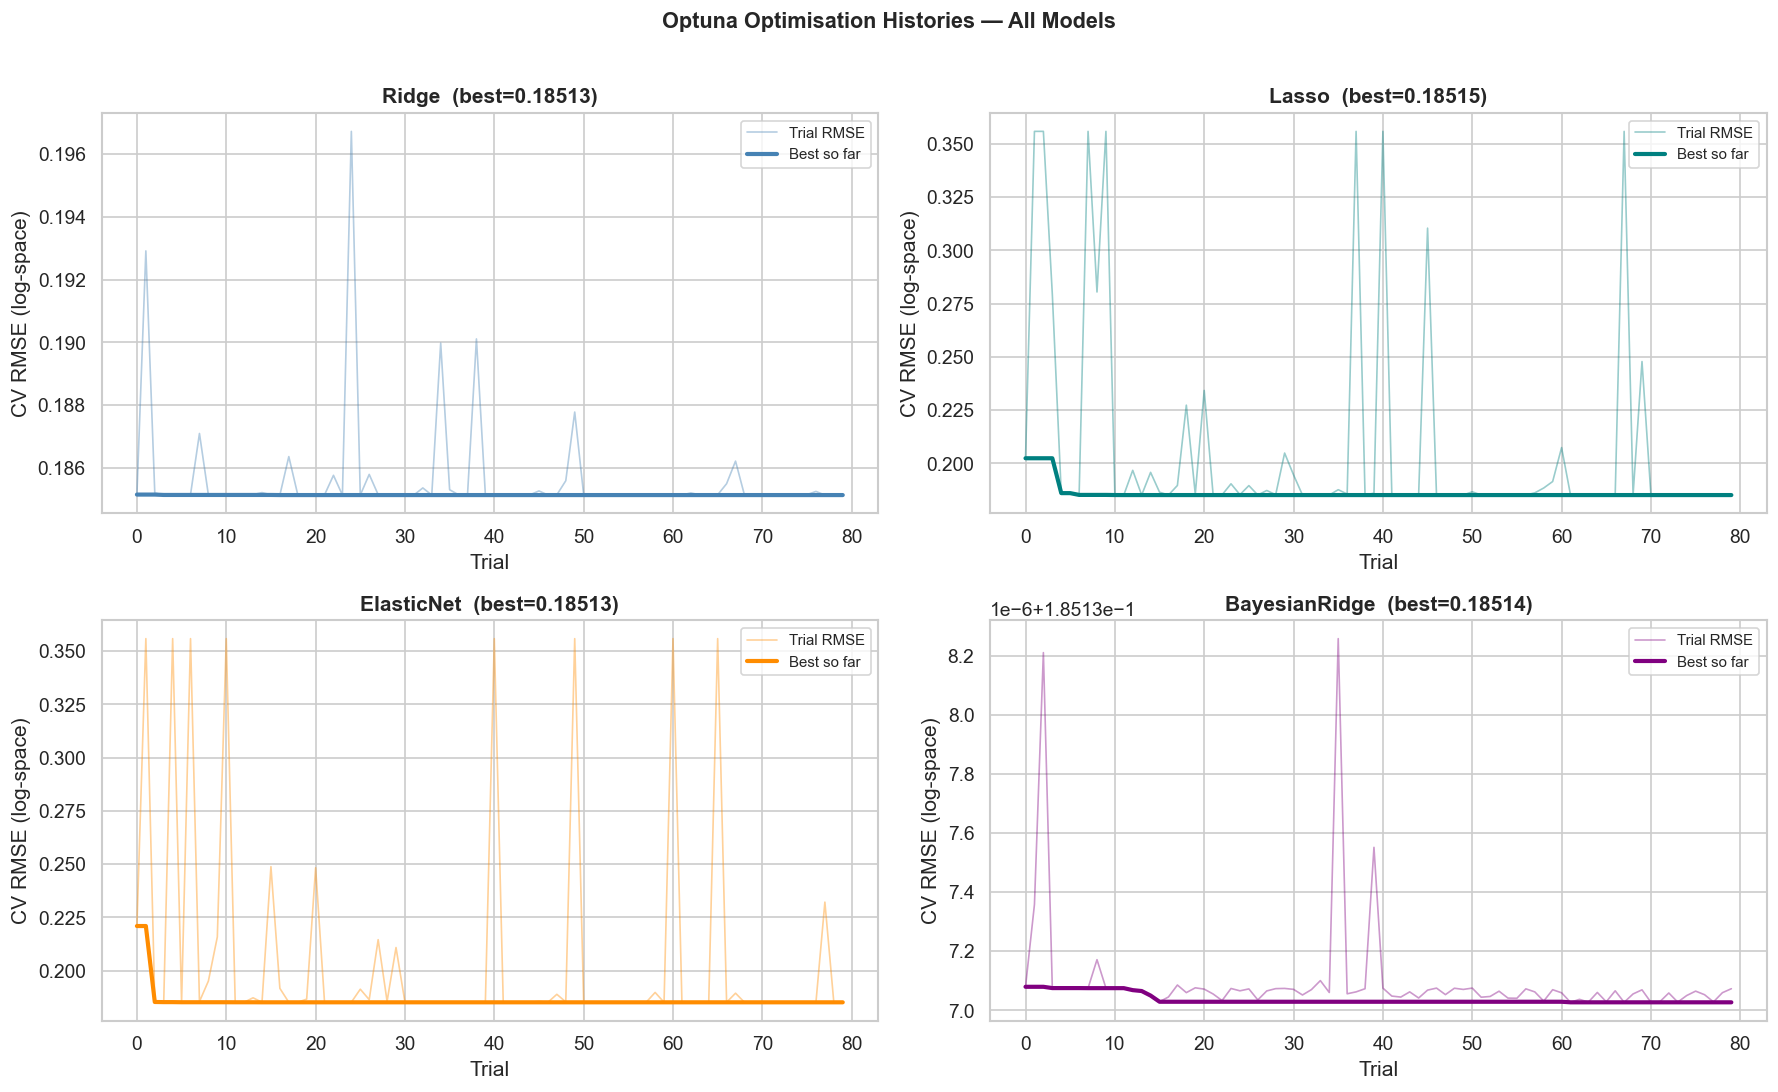

In [28]:
# ── 6.6 Optuna Results: Before vs After Comparison ───────────────────────────
def test_rmse(model, X_te, y_te):
    pred = np.expm1(model.predict(X_te))
    true = np.expm1(y_te.values)
    return np.sqrt(mean_squared_error(true, pred)) * 100_000

comparison = [
    ('Ridge',        fitted_models_engineered['Ridge'],      ridge_opt),
    ('Lasso',        fitted_models_engineered['Lasso'],      lasso_opt),
    ('ElasticNet',   fitted_models_engineered['ElasticNet'], enet_opt),
    ('BayesianRidge', br,                                    br_opt),
]

rows = []
for name, m_before, m_after in comparison:
    rb = test_rmse(m_before, X_test_fe, y_test)
    ra = test_rmse(m_after,  X_test_fe, y_test)
    rows.append({
        'Model'          : name,
        'Before ($)'     : f'{rb:,.0f}',
        'After ($)'      : f'{ra:,.0f}',
        'Improvement ($)': f'{rb - ra:+,.0f}'
    })

print('Optuna Tuning Impact — Test RMSE (USD):')
print(pd.DataFrame(rows).to_string(index=False))

# Optimisation history plots
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
studies_info = [
    ('Ridge',         study_ridge, 'steelblue'),
    ('Lasso',         study_lasso, 'teal'),
    ('ElasticNet',    study_enet,  'darkorange'),
    ('BayesianRidge', study_br,    'purple'),
]
for ax, (name, study, color) in zip(axes.flatten(), studies_info):
    vals = [t.value for t in study.trials if t.value is not None]
    best = np.minimum.accumulate(vals)
    ax.plot(vals, alpha=0.4, color=color, linewidth=1,   label='Trial RMSE')
    ax.plot(best, color=color,             linewidth=2.5, label='Best so far')
    ax.set_title(f'{name}  (best={study.best_value:.5f})', fontweight='bold')
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV RMSE (log-space)')
    ax.legend(fontsize=9)

plt.suptitle('Optuna Optimisation Histories — All Models',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('10_optuna_histories.png', dpi=150, bbox_inches='tight')
plt.show()


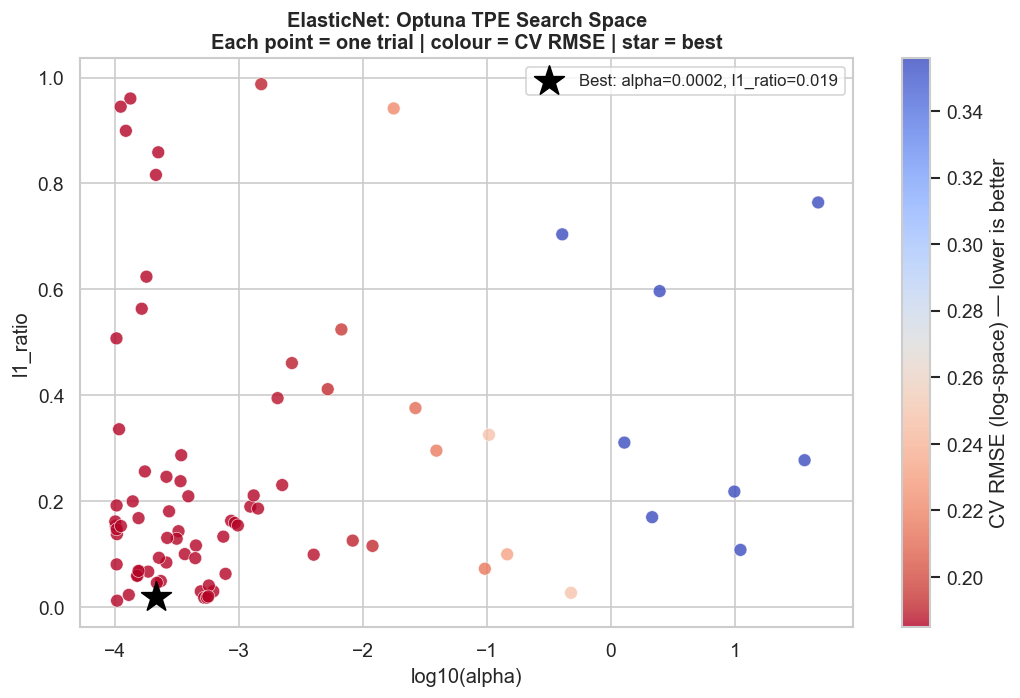

In [29]:
# ── 6.7 ElasticNet: alpha x l1_ratio Search Space Scatter ────────────────────
#
# Each point = one Optuna trial. Colour = CV RMSE (dark = good).
# The star marks the best (alpha, l1_ratio) found by TPE.
# If the star sits in a dense dark cluster, TPE has converged.
# If it sits at the edge of the sampled region, increase N_TRIALS.
#
trials_enet  = [t for t in study_enet.trials if t.value is not None]
alphas_tried = [t.params['alpha']    for t in trials_enet]
l1_tried     = [t.params['l1_ratio'] for t in trials_enet]
vals_tried   = [t.value              for t in trials_enet]

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    np.log10(alphas_tried), l1_tried,
    c=vals_tried, cmap='coolwarm_r',
    s=60, alpha=0.8, edgecolors='white', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='CV RMSE (log-space) — lower is better')
ax.scatter(
    np.log10(best_enet_alpha), best_enet_l1ratio,
    marker='*', s=350, color='black', zorder=5,
    label=f'Best: alpha={best_enet_alpha:.4f}, l1_ratio={best_enet_l1ratio:.3f}'
)
ax.set_xlabel('log10(alpha)', fontsize=12)
ax.set_ylabel('l1_ratio', fontsize=12)
ax.set_title('ElasticNet: Optuna TPE Search Space\n'
             'Each point = one trial | colour = CV RMSE | star = best',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('11_optuna_enet_contour.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 7 — SHAP: Global & Local Interpretability

### What SHAP values mean
SHAP (SHapley Additive exPlanations) answers: **how much did each feature push this
prediction above or below the baseline (mean prediction)?**

```
prediction_i = base_value + sum(shap_value(i, j) for all features j)
```
The `base_value` is `mean(y_train_pred)`. SHAP values are additive and sum exactly
to the gap between the prediction and that baseline.

### Which explainer for which model
| Model | Explainer | Speed | Exactness |
|---|---|---|---|
| Ridge (linear) | `shap.LinearExplainer` | Very fast | Exact |
| Poly(2)+Ridge | `shap.LinearExplainer` | Fast | Exact (on expanded space) |

Both Ridge variants are linear in their feature space — `LinearExplainer` computes
exact Shapley values using the feature covariance matrix. No sampling needed.

### Three plots per model
1. **Beeswarm (global)** — each dot = one test sample. X-axis = SHAP value.
   Colour = actual feature value. Shows direction AND magnitude for every sample.
2. **Bar chart** — mean |SHAP| per feature. Single importance number.
3. **Waterfall (local)** — one prediction broken down feature by feature.
   Answers: *why did this specific house get this specific price?*


In [30]:
# ── 7.0 Install SHAP (if not already present) ─────────────────────────────────
import importlib, subprocess, sys
if importlib.util.find_spec('shap') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '--quiet'])
    print('shap installed')
else:
    print('shap already available')


shap already available


In [31]:
# ── 7.1 SHAP Setup — Feature Names + DataFrames ───────────────────────────────
import shap
shap.initjs()  # enables inline JS visualisations in Jupyter

# Reconstruct full feature name list from the ColumnTransformer
ct_step = feature_pipeline.named_steps['preprocessor']
cat_feat_names = ct_step.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
all_feat_names = np.array(NUMERIC_FEATURES + list(cat_feat_names))

# Wrap numpy arrays as DataFrames so SHAP shows feature labels
X_train_fe_df = pd.DataFrame(X_train_fe, columns=all_feat_names)
X_test_fe_df  = pd.DataFrame(X_test_fe,  columns=all_feat_names)

print(f'Feature matrix shape : {X_train_fe_df.shape}')
print(f'Feature names ({len(all_feat_names)}): {list(all_feat_names[:6])} ... {list(all_feat_names[-3:])}')


Feature matrix shape : (16499, 26)
Feature names (26): [np.str_('MedInc'), np.str_('HouseAge'), np.str_('AveRooms'), np.str_('AveBedrms'), np.str_('Population'), np.str_('AveOccup')] ... [np.str_('geo_cluster_7'), np.str_('geo_cluster_8'), np.str_('geo_cluster_9')]


In [32]:
# ── 7.2 SHAP on Ridge — LinearExplainer ──────────────────────────────────────
#
# We use the Optuna-tuned Ridge (ridge_opt) — the best Ridge we have.
#
# feature_perturbation='correlation_dependent' accounts for correlated features
# when computing the background distribution. More accurate than 'interventional'
# when features are correlated (they are: MedInc correlates with income_rooms etc.)
#
explainer_ridge = shap.LinearExplainer(
    ridge_opt,
    X_train_fe_df,
    feature_perturbation='correlation_dependent'
)
shap_values_ridge = explainer_ridge.shap_values(X_test_fe_df)

# Sanity check: base + sum(shap) should equal prediction
sample_idx = 0
pred_check = ridge_opt.predict(X_test_fe_df.iloc[[sample_idx]])[0]
shap_sum   = explainer_ridge.expected_value + shap_values_ridge[sample_idx].sum()
print(f'Sanity check (sample {sample_idx}):')
print(f'  Model prediction  : {pred_check:.6f}')
print(f'  base + sum(SHAP)  : {shap_sum:.6f}')
print(f'  Match             : {abs(pred_check - shap_sum) < 1e-6}')
print(f'\nSHAP values shape: {shap_values_ridge.shape}  (n_test x n_features)')


Estimating transforms: 100%|██████████| 1000/1000 [00:01<00:00, 817.21it/s]

Sanity check (sample 0):
  Model prediction  : 0.642701
  base + sum(SHAP)  : 0.642701
  Match             : True

SHAP values shape: (4125, 26)  (n_test x n_features)


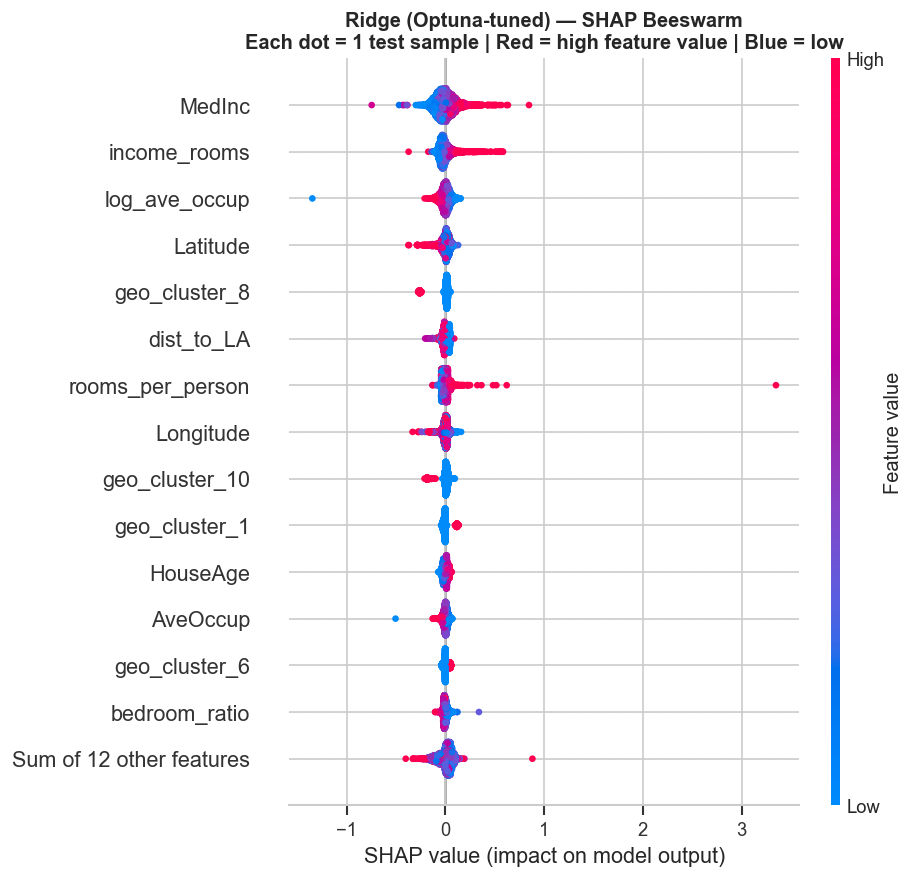

In [33]:
# ── 7.3 Ridge SHAP — Beeswarm (Global) ───────────────────────────────────────
#
# How to read this:
#   - Y-axis: features ranked by mean |SHAP| (most important at top)
#   - X-axis: SHAP value — positive = pushes price UP, negative = pushes DOWN
#   - Dot colour: red = high feature value, blue = low feature value
#
# Example reading: 'MedInc' dots are red on the right side →
#   high median income strongly pushes price UP
# 'dist_to_LA' red dots are on the left →
#   high distance from LA (far away) pushes price DOWN
#
shap_exp_ridge = shap.Explanation(
    values        = shap_values_ridge,
    base_values   = explainer_ridge.expected_value,
    data          = X_test_fe_df.values,
    feature_names = list(all_feat_names)
)

plt.figure(figsize=(11, 7))
shap.plots.beeswarm(shap_exp_ridge, max_display=15, show=False)
plt.title('Ridge (Optuna-tuned) — SHAP Beeswarm\n'
          'Each dot = 1 test sample | Red = high feature value | Blue = low',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('12_shap_ridge_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


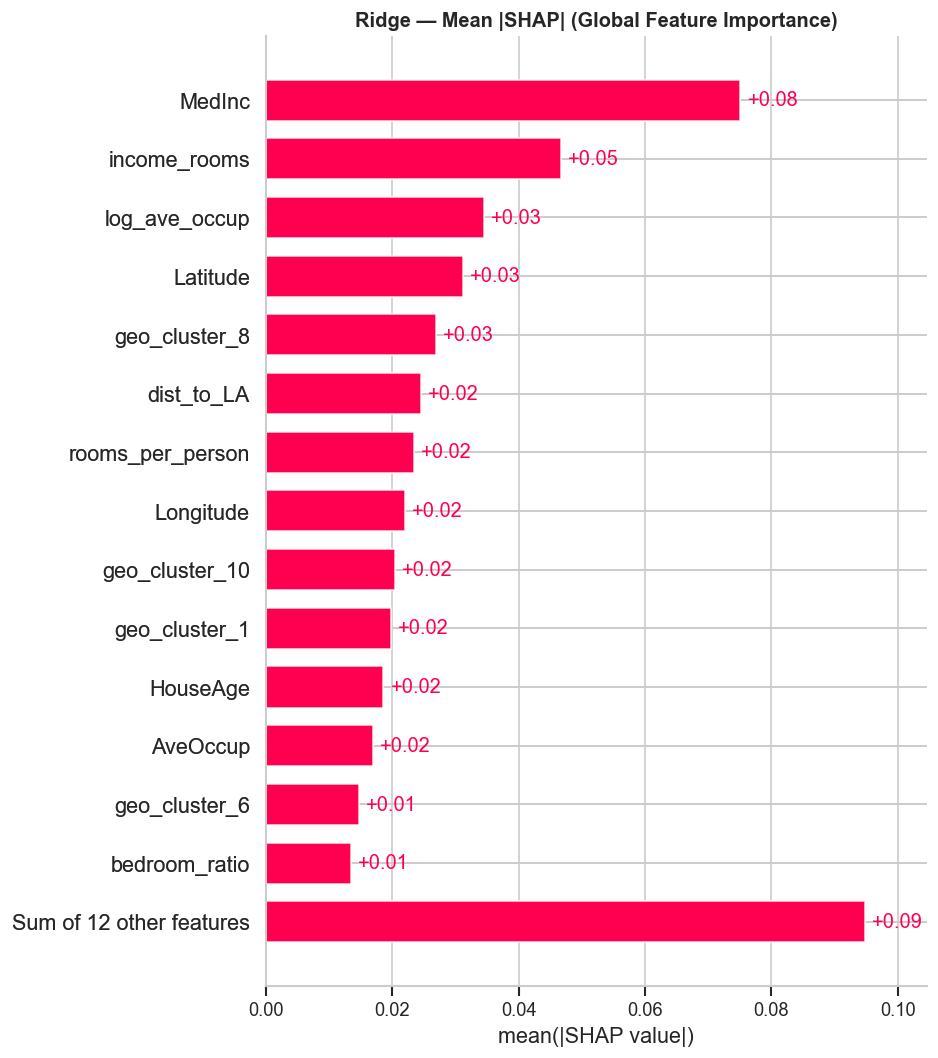

Waterfall — most-mispredicted sample (index 2530):
  Actual    : 0.830 ($100K)
  Predicted : 18.921 ($100K)
  Error     : $1,809,058


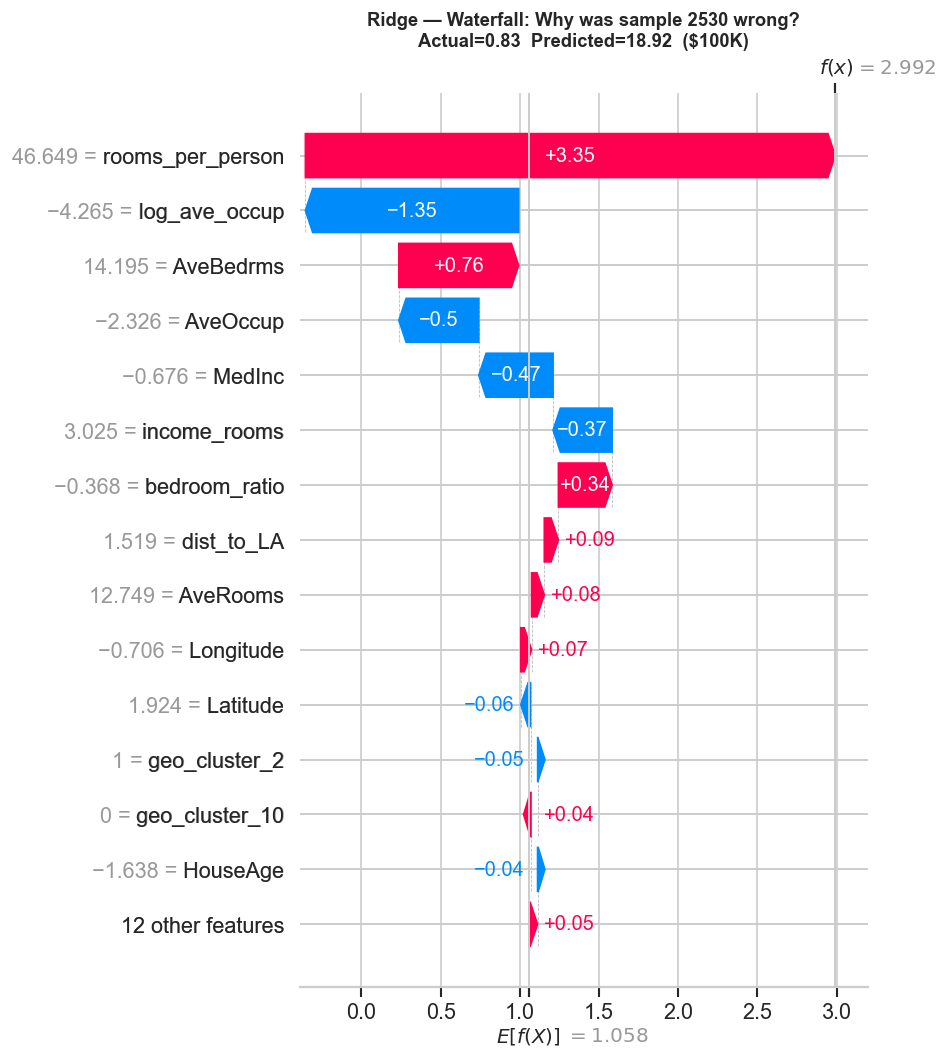

In [34]:
# ── 7.4 Ridge SHAP — Bar Chart + Waterfall (Local) ───────────────────────────

# Bar chart: mean |SHAP| — single importance number per feature
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_exp_ridge, max_display=15, show=False)
plt.title('Ridge — Mean |SHAP| (Global Feature Importance)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('13_shap_ridge_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Waterfall for the most-mispredicted test sample
# This answers: 'why did the model get this house so wrong?'
pred_ridge_test = ridge_opt.predict(X_test_fe_df)
errors_ridge    = np.abs(pred_ridge_test - y_test.values)
worst_idx       = int(np.argmax(errors_ridge))

print(f'Waterfall — most-mispredicted sample (index {worst_idx}):')
print(f'  Actual    : {np.expm1(y_test.values[worst_idx]):.3f} ($100K)')
print(f'  Predicted : {np.expm1(pred_ridge_test[worst_idx]):.3f} ($100K)')
print(f'  Error     : ${abs(np.expm1(y_test.values[worst_idx]) - np.expm1(pred_ridge_test[worst_idx]))*100_000:,.0f}')

plt.figure(figsize=(11, 7))
shap.plots.waterfall(shap_exp_ridge[worst_idx], max_display=15, show=False)
plt.title(
    f'Ridge — Waterfall: Why was sample {worst_idx} wrong?\n'
    f'Actual={np.expm1(y_test.values[worst_idx]):.2f}  '
    f'Predicted={np.expm1(pred_ridge_test[worst_idx]):.2f}  ($100K)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('14_shap_ridge_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()


In [35]:
# ── 7.5 SHAP on Poly(2)+Ridge — LinearExplainer on expanded space ─────────────
#
# Poly(2)+Ridge is linear in the 135-dimensional polynomial feature space.
# We extract the Ridge estimator from the pipeline and run LinearExplainer
# on the already-expanded matrix.
#
# Pipeline structure:
#   poly_ridge_pipeline
#     [0] engineer     -> CaliforniaFeatureEngineer
#     [1] preprocessor -> ColumnTransformer (scaler+poly for numeric, OHE for cat)
#     [2] ridge        -> Ridge (the linear model SHAP explains)
#
poly_prep_steps = poly_ridge_pipeline[:-1]   # everything before the Ridge
ridge_final     = poly_ridge_pipeline.named_steps['ridge']

# Get expanded matrices
X_train_poly_exp = poly_prep_steps.transform(X_train)
X_test_poly_exp  = poly_prep_steps.transform(X_test)

# Build poly feature name list
poly_step_obj  = poly_ridge_pipeline.named_steps['preprocessor']\
                     .named_transformers_['num'].named_steps['poly']
poly_cat_obj   = poly_ridge_pipeline.named_steps['preprocessor']\
                     .named_transformers_['cat']
poly_num_names = poly_step_obj.get_feature_names_out(input_features=NUMERIC_FEATURES)
poly_cat_names = poly_cat_obj.get_feature_names_out(CATEGORICAL_FEATURES)
poly_all_names = np.array(list(poly_num_names) + list(poly_cat_names))

X_train_poly_df = pd.DataFrame(X_train_poly_exp, columns=poly_all_names)
X_test_poly_df  = pd.DataFrame(X_test_poly_exp,  columns=poly_all_names)

print(f'Poly expanded features : {len(poly_all_names)}')
print(f'Sample interaction terms: {[n for n in poly_num_names if "*" in n][:5]}')

explainer_poly   = shap.LinearExplainer(
    ridge_final,
    X_train_poly_df,
    feature_perturbation='correlation_dependent'
)
shap_values_poly = explainer_poly.shap_values(X_test_poly_df)
print(f'Poly SHAP values shape : {shap_values_poly.shape}')


Poly expanded features : 146
Sample interaction terms: []


Estimating transforms: 100%|██████████| 1000/1000 [01:02<00:00, 15.94it/s]

Poly SHAP values shape : (4125, 146)


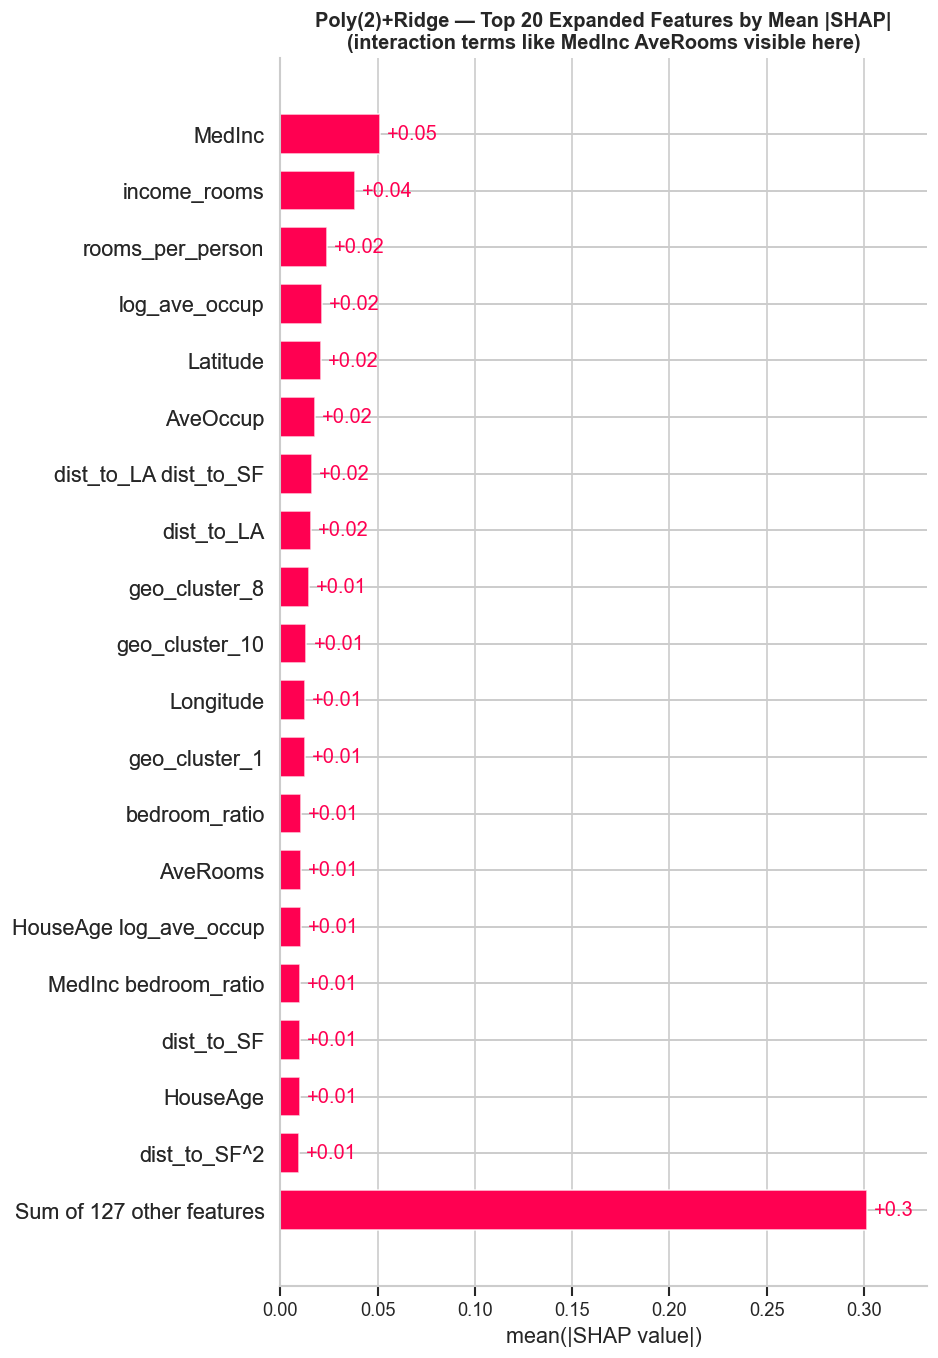

Waterfall — median-error sample (index 4031):
  Actual    : 1.740 ($100K)
  Predicted : 2.008 ($100K)


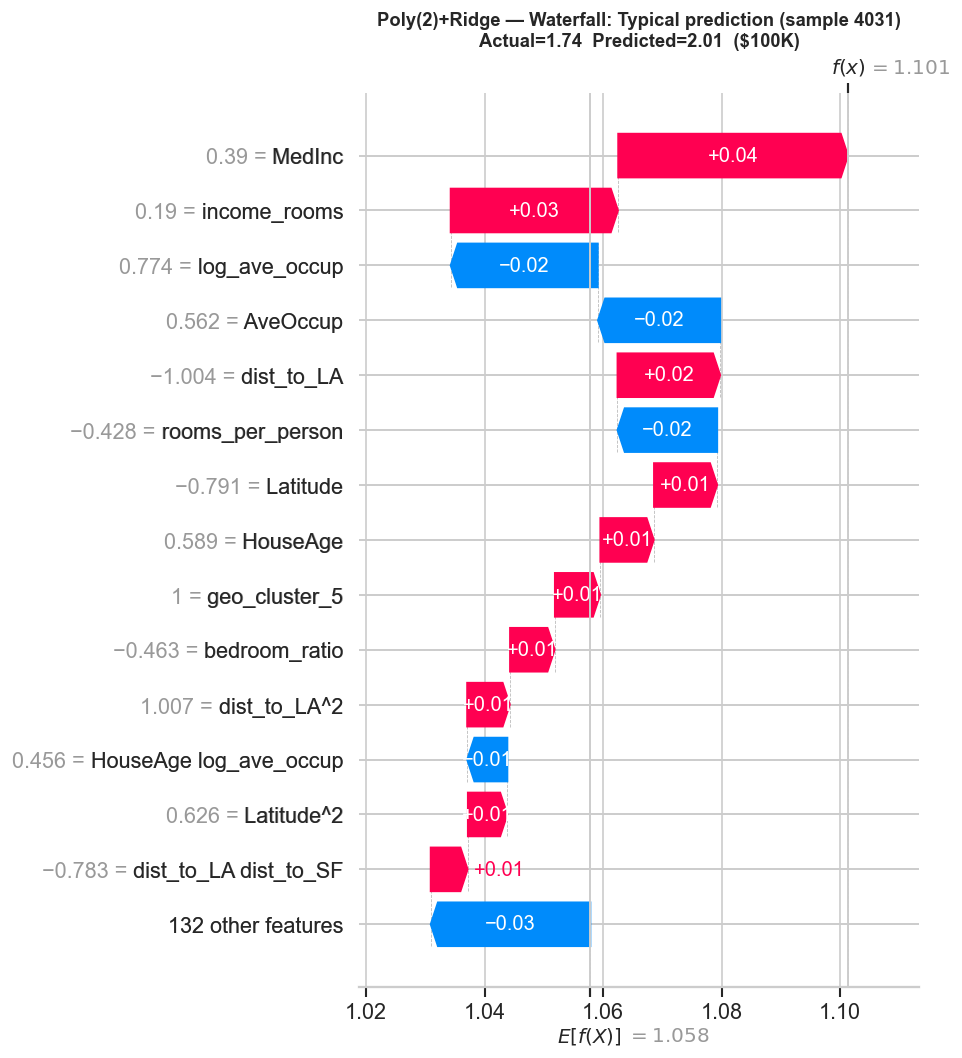

In [36]:
# ── 7.6 Poly(2)+Ridge SHAP — Bar + Waterfall ─────────────────────────────────

shap_exp_poly = shap.Explanation(
    values        = shap_values_poly,
    base_values   = explainer_poly.expected_value,
    data          = X_test_poly_df.values,
    feature_names = list(poly_all_names)
)

# Bar chart — top 20 polynomial features by mean |SHAP|
# Interaction terms like 'MedInc AveRooms' or 'MedInc^2' often appear high here
plt.figure(figsize=(11, 8))
shap.plots.bar(shap_exp_poly, max_display=20, show=False)
plt.title('Poly(2)+Ridge — Top 20 Expanded Features by Mean |SHAP|\n'
          '(interaction terms like MedInc AveRooms visible here)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('15_shap_poly_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Waterfall for the median-error test sample
# Median = a 'typical' prediction, not an extreme one — more representative story
pred_poly_test = ridge_final.predict(X_test_poly_df)
errors_poly    = np.abs(pred_poly_test - y_test.values)
median_idx     = int(np.argsort(errors_poly)[len(errors_poly) // 2])

print(f'Waterfall — median-error sample (index {median_idx}):')
print(f'  Actual    : {np.expm1(y_test.values[median_idx]):.3f} ($100K)')
print(f'  Predicted : {np.expm1(pred_poly_test[median_idx]):.3f} ($100K)')

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_exp_poly[median_idx], max_display=15, show=False)
plt.title(
    f'Poly(2)+Ridge — Waterfall: Typical prediction (sample {median_idx})\n'
    f'Actual={np.expm1(y_test.values[median_idx]):.2f}  '
    f'Predicted={np.expm1(pred_poly_test[median_idx]):.2f}  ($100K)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('16_shap_poly_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()


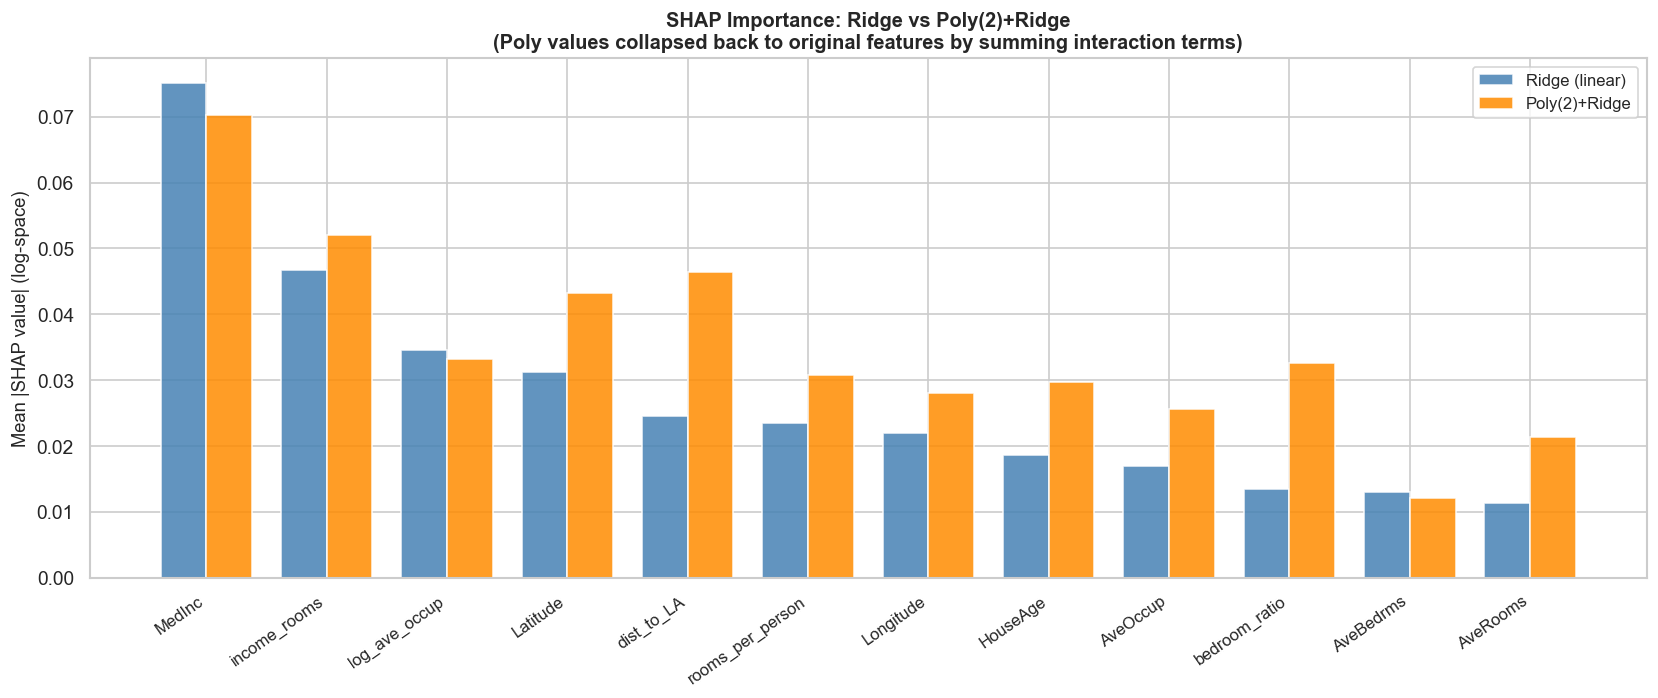

         Feature  Ridge |SHAP|  Poly  |SHAP|  Poly/Ridge ratio
          MedInc       0.07512       0.07023              0.93
    income_rooms       0.04666       0.05203              1.12
   log_ave_occup       0.03456       0.03324              0.96
        Latitude       0.03120       0.04329              1.39
      dist_to_LA       0.02457       0.04639              1.89
rooms_per_person       0.02346       0.03082              1.31
       Longitude       0.02204       0.02807              1.27
        HouseAge       0.01860       0.02967              1.60
        AveOccup       0.01699       0.02562              1.51
   bedroom_ratio       0.01352       0.03265              2.42
       AveBedrms       0.01308       0.01207              0.92
        AveRooms       0.01129       0.02134              1.89

Ratio > 1: polynomial expansion amplified that feature contribution.
Ratio < 1: feature was more directly useful in linear form.


In [37]:
# ── 7.7 SHAP Comparison: Ridge vs Poly — collapsed to original features ────────
#
# For Poly(2)+Ridge, we collapse SHAP values back to the 15 original numeric
# engineered features by summing all polynomial terms that derive from each.
# This makes the comparison fair — both models on the same feature vocabulary.
#
# Example collapse: MedInc, MedInc^2, MedInc AveRooms, MedInc HouseAge ...
#   -> all sum into 'MedInc' SHAP contribution for the poly model
#
n_num = len(NUMERIC_FEATURES)
orig_shap_poly = np.zeros((shap_values_poly.shape[0], n_num))
for j, orig_name in enumerate(NUMERIC_FEATURES):
    # A poly term 'belongs' to an original feature if the original name appears in it
    mask = np.array([orig_name in pname for pname in poly_all_names])
    orig_shap_poly[:, j] = shap_values_poly[:, mask].sum(axis=1)

mean_shap_ridge_num = np.abs(shap_values_ridge[:, :n_num]).mean(axis=0)
mean_shap_poly_num  = np.abs(orig_shap_poly).mean(axis=0)

# Sort by Ridge importance, show top 12
sort_idx    = np.argsort(mean_shap_ridge_num)[::-1][:12]
feat_sorted = [NUMERIC_FEATURES[i] for i in sort_idx]
shap_r_s    = mean_shap_ridge_num[sort_idx]
shap_p_s    = mean_shap_poly_num[sort_idx]

x = np.arange(len(feat_sorted))
w = 0.38
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, shap_r_s, w, label='Ridge (linear)',  color='steelblue',  alpha=0.85, edgecolor='white')
ax.bar(x + w/2, shap_p_s, w, label='Poly(2)+Ridge',   color='darkorange', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(feat_sorted, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Mean |SHAP value| (log-space)', fontsize=11)
ax.set_title(
    'SHAP Importance: Ridge vs Poly(2)+Ridge\n'
    '(Poly values collapsed back to original features by summing interaction terms)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('17_shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

df_cmp = pd.DataFrame({
    'Feature'         : feat_sorted,
    'Ridge |SHAP|'    : shap_r_s.round(5),
    'Poly  |SHAP|'    : shap_p_s.round(5),
    'Poly/Ridge ratio': (shap_p_s / (shap_r_s + 1e-9)).round(2)
})
print(df_cmp.to_string(index=False))
print('\nRatio > 1: polynomial expansion amplified that feature contribution.')
print('Ratio < 1: feature was more directly useful in linear form.')
